# 🐦 Twitter Data — EDA, Visualization & Statistical Analysis

> *"Social media is not just a spoke in the wheel of marketing. It's becoming the way entire bicycles are built." — Ryan Lilly*

This notebook performs a complete **Exploratory Data Analysis** on a real-world Twitter dataset containing **100,000 tweets** about AWS / cloud technology topics.

**Dataset:** 100,000 tweets | 14 columns | Topics: AWS, Cloud, DevOps

---

## 📋 Table of Contents
1. [Setup & Data Loading](#s1)
2. [Dataset Overview & Quality](#s2)
3. [Univariate Analysis](#s3)
4. [Engagement Analysis — Reach, Retweets, Likes](#s4)
5. [Temporal Analysis — Hour, Day, Weekday](#s5)
6. [Language & Geographic Analysis](#s6)
7. [Sentiment Analysis](#s7)
8. [Influencer & Klout Analysis](#s8)
9. [Correlation & Bivariate Analysis](#s9)
10. [Statistical Hypothesis Testing](#s10)
11. [Key Insights & Summary](#s11)


## 1. Setup & Data Loading 🔧 <a id='s1'></a>

### Everyday Example
Before reading a book, you check the title, author, and table of contents. We do the same — load our tools and take a first look at the data.


In [1]:
# ============================================================
# SECTION 1 — Setup & Data Loading
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats
from collections import Counter
import re

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('Libraries loaded successfully!')
print(f'Pandas : {pd.__version__}')
print(f'NumPy  : {np.__version__}')


Libraries loaded successfully!
Pandas : 2.3.3
NumPy  : 2.0.2


In [2]:
# Load dataset — latin-1 encoding handles special characters in tweet text
df_raw = pd.read_csv('/kaggle/input/datasets/abbas829/social-media-performance-and-sentiment-dataset/Twitterdatainsheets.csv', encoding='latin-1', low_memory=False)

# Strip leading/trailing spaces from column names
df_raw.columns = df_raw.columns.str.strip()

print(f'Shape   : {df_raw.shape}')
print(f'Columns : {df_raw.columns.tolist()}')
df_raw.head()


Shape   : (100001, 14)
Columns : ['TweetID', 'Weekday', 'Hour', 'Day', 'Lang', 'IsReshare', 'Reach', 'RetweetCount', 'Likes', 'Klout', 'Sentiment', 'text', 'LocationID', 'UserID']


,TweetID,Weekday,Hour,Day,Lang,IsReshare,Reach,RetweetCount,Likes,Klout,Sentiment,text,LocationID,UserID
0,tw-682712873332805633,Thursday,17.0,31.0,en,False,44.0,0.0,0.0,35.0,0.0,We are hiring: Senior Software Engineer - Prot...,3751.0,tw-40932430
1,tw-682713045357998080,Thursday,17.0,31.0,en,True,1810.0,5.0,0.0,53.0,2.0,RT @CodeMineStatus: This is true Amazon Web Se...,3989.0,tw-3179389829
2,tw-682713219375476736,Thursday,17.0,31.0,en,False,282.0,0.0,0.0,47.0,0.0,Devops Engineer Aws Ansible Cassandra Mysql Ub...,3741.0,tw-4624808414
3,tw-682713436967579648,Thursday,17.0,31.0,en,False,2087.0,4.0,0.0,53.0,0.0,Happy New Year to all those AWS instances of o...,3753.0,tw-356447127
4,tw-682714048199311366,Thursday,17.0,31.0,en,False,953.0,0.0,0.0,47.0,0.0,Amazon is hiring! #Sr. #International Tax Mana...,3751.0,tw-3172686669


In [3]:
# Clean up and type-cast
df = df_raw.copy()

# Drop the single all-NaN header row (row 0 is sometimes a duplicate header)
df = df.dropna(how='all').reset_index(drop=True)

# Convert boolean-like IsReshare to proper bool
df['IsReshare'] = df['IsReshare'].map({True: True, False: False,
                                        'True': True, 'False': False}).astype('boolean')

# Numeric columns
for col in ['Hour', 'Day', 'Reach', 'RetweetCount', 'Likes', 'Klout', 'Sentiment', 'LocationID']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Hour as integer
df['Hour'] = df['Hour'].astype('Int64')

print(f'Clean shape : {df.shape}')
print(df.dtypes)


Clean shape : (100000, 14)
TweetID          object
Weekday          object
Hour              Int64
Day             float64
Lang             object
IsReshare       boolean
Reach           float64
RetweetCount    float64
Likes           float64
Klout           float64
Sentiment       float64
text             object
LocationID      float64
UserID           object
dtype: object


## 2. Dataset Overview & Quality 🔍 <a id='s2'></a>

### Everyday Example
A doctor checks a patient's vitals before diagnosis. We check our data's health — shape, types, missing values, duplicates.

| Column | Description |
|---|---|
| TweetID | Unique tweet identifier |
| Weekday | Day of the week the tweet was posted |
| Hour | Hour of the day (0–23) |
| Day | Day of the month |
| Lang | Language code (en, es, fr, …) |
| IsReshare | Whether the tweet is a retweet |
| Reach | Estimated audience reach |
| RetweetCount | Number of retweets |
| Likes | Number of likes |
| Klout | Klout score of the author (0–100, influence metric) |
| Sentiment | Sentiment score (negative = negative, positive = positive) |
| text | Raw tweet text |
| LocationID | Numeric location identifier |
| UserID | Unique user identifier |


In [4]:
# ============================================================
# SECTION 2 — Dataset Overview
# ============================================================
print(f'Rows    : {len(df):,}')
print(f'Columns : {df.shape[1]}')
print(f'Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.info()


Rows    : 100,000
Columns : 14
Memory  : 55.2 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   TweetID       100000 non-null  object 
 1   Weekday       100000 non-null  object 
 2   Hour          100000 non-null  Int64  
 3   Day           100000 non-null  float64
 4   Lang          100000 non-null  object 
 5   IsReshare     100000 non-null  boolean
 6   Reach         100000 non-null  float64
 7   RetweetCount  100000 non-null  float64
 8   Likes         100000 non-null  float64
 9   Klout         100000 non-null  float64
 10  Sentiment     100000 non-null  float64
 11  text          100000 non-null  object 
 12  LocationID    100000 non-null  float64
 13  UserID        100000 non-null  object 
dtypes: Int64(1), boolean(1), float64(7), object(5)
memory usage: 10.2+ MB


In [5]:
# Descriptive statistics
NUM_COLS = ['Reach', 'RetweetCount', 'Likes', 'Klout', 'Sentiment', 'Hour', 'Day']
df[NUM_COLS].describe().T.round(2).style.background_gradient(cmap='Blues')


,count,mean,std,min,25%,50%,75%,max
Reach,100000.000000,8542.395980,88670.266421,0.000000,151.000000,448.500000,1496.000000,10342452.000000
RetweetCount,100000.000000,8.052750,97.863474,0.000000,0.000000,0.000000,3.000000,26127.000000
Likes,100000.000000,0.152770,2.583633,0.000000,0.000000,0.000000,0.000000,133.000000
Klout,100000.000000,40.389260,13.636513,0.000000,32.000000,43.000000,49.000000,99.000000
Sentiment,100000.000000,0.380921,1.046559,-6.000000,0.000000,0.000000,0.666667,7.333333
Hour,100000.000000,11.412490,6.053577,0.000000,7.000000,11.000000,16.000000,23.000000
Day,100000.000000,15.894960,8.399852,1.000000,9.000000,16.000000,23.000000,31.000000


In [6]:
# Missing value analysis
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct'  : (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing Pct', ascending=False)
print(missing[missing['Missing Count'] > 0].to_string())


Empty DataFrame
Columns: [Missing Count, Missing Pct]
Index: []


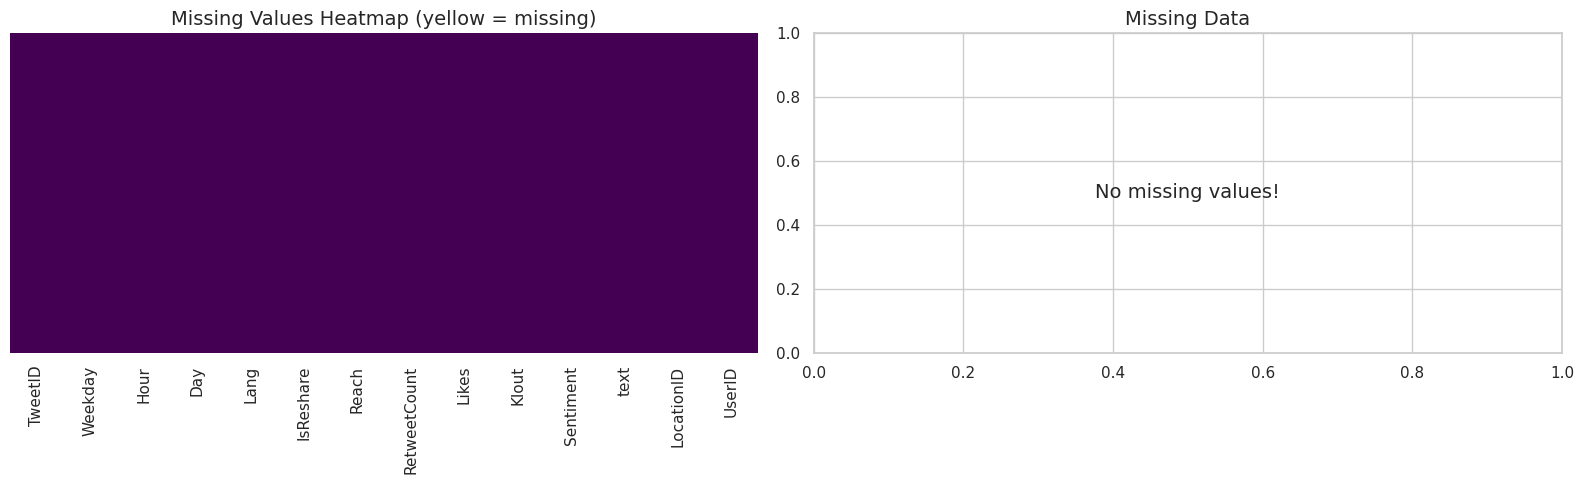

In [7]:
# Visualise missing values
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap (yellow = missing)')

mv = missing[missing['Missing Pct'] > 0]
if len(mv):
    axes[1].barh(mv.index, mv['Missing Pct'], color='salmon', edgecolor='black')
    axes[1].set_xlabel('Missing %')
    axes[1].set_title('Missing Data % per Column')
else:
    axes[1].text(0.5, 0.5, 'No missing values!', ha='center', va='center', fontsize=14)
    axes[1].set_title('Missing Data')

plt.tight_layout(); plt.show()


In [8]:
# Duplicate check
dupes = df.duplicated(subset='TweetID').sum()
print(f'Duplicate TweetIDs : {dupes}')
print(f'Unique users       : {df["UserID"].nunique():,}')
print(f'Unique languages   : {df["Lang"].nunique()}')
print(f'IsReshare breakdown:\n{df["IsReshare"].value_counts().to_string()}')
print(f'Weekdays present   : {df["Weekday"].dropna().unique().tolist()}')


Duplicate TweetIDs : 0
Unique users       : 33,213
Unique languages   : 36
IsReshare breakdown:
IsReshare
False    64538
True     35462
Weekdays present   : ['Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday']


## 3. Univariate Analysis 📊 <a id='s3'></a>

### Everyday Example
Before comparing students, a teacher first looks at the score distribution of a single exam. We examine each variable on its own first.


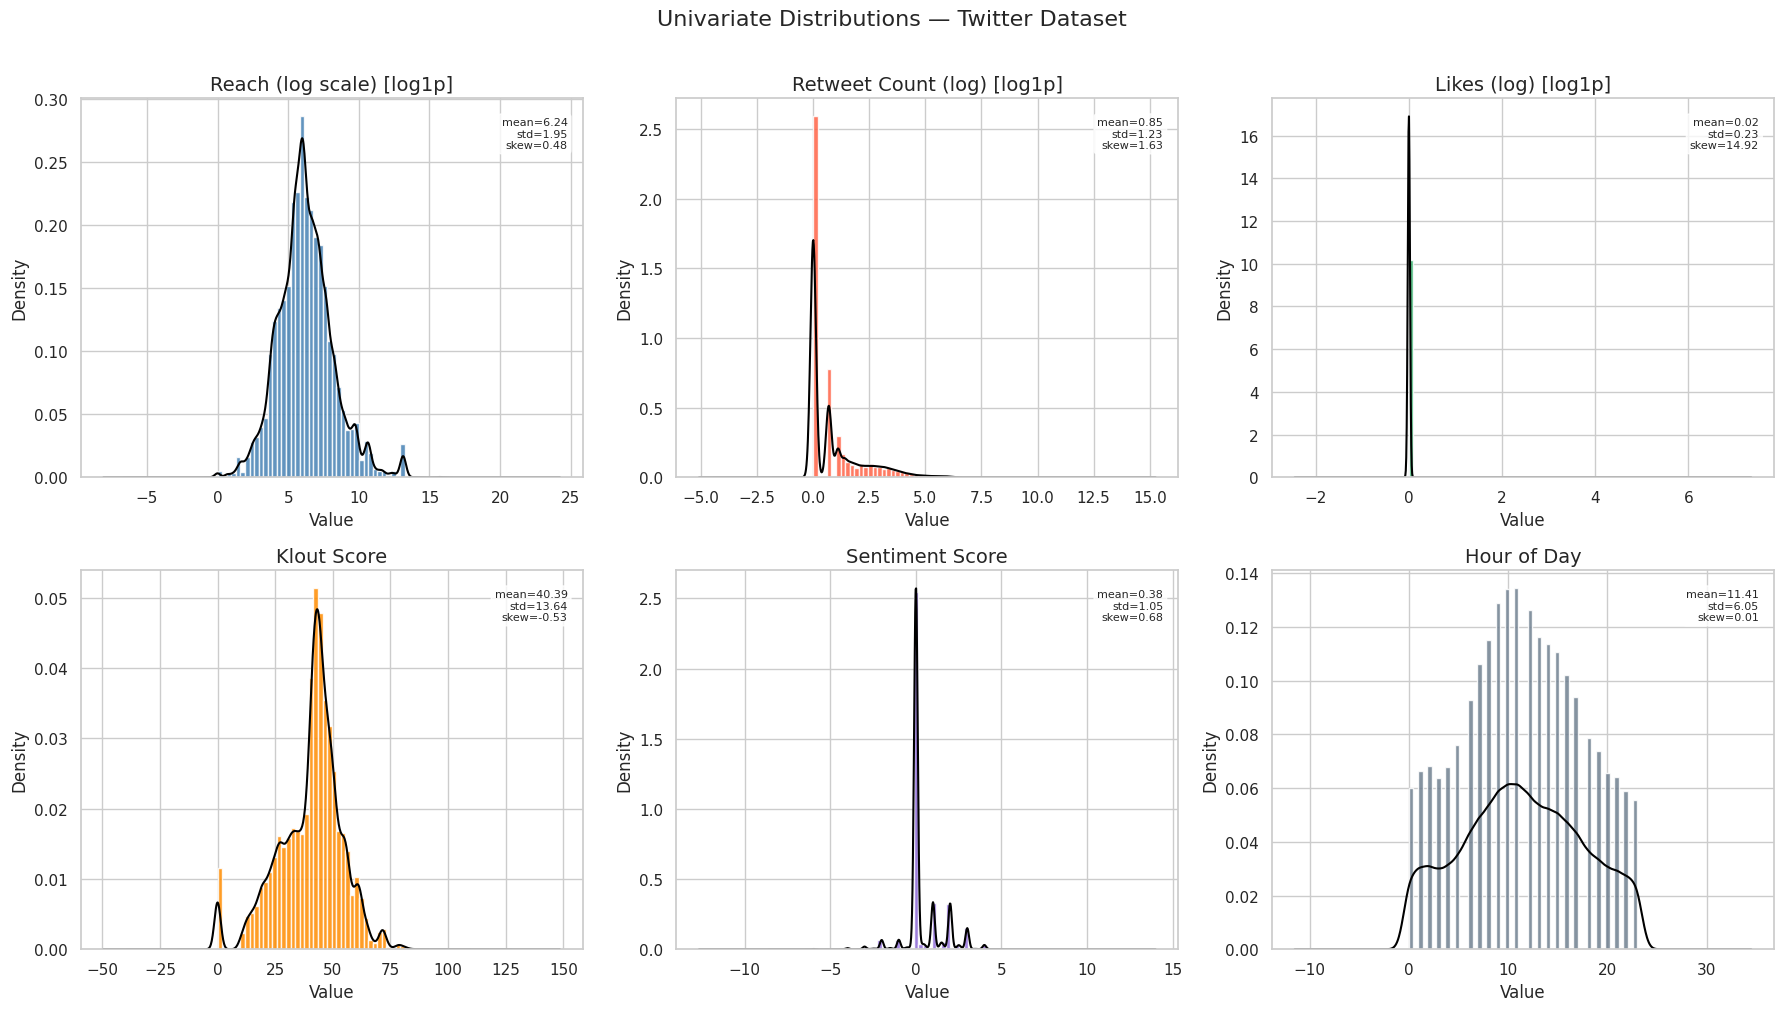

In [9]:
# ============================================================
# SECTION 3 — Univariate Analysis
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

plot_vars = [
    ('Reach',        'Reach (log scale)',       'steelblue'),
    ('RetweetCount', 'Retweet Count (log)',      'tomato'),
    ('Likes',        'Likes (log)',              'mediumseagreen'),
    ('Klout',        'Klout Score',              'darkorange'),
    ('Sentiment',    'Sentiment Score',          'mediumpurple'),
    ('Hour',         'Hour of Day',              'slategray'),
]

for ax, (col, label, color) in zip(axes, plot_vars):
    data = df[col].dropna()
    if col in ['Reach', 'RetweetCount', 'Likes']:
        data = np.log1p(data)
        label += ' [log1p]'
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85, density=True)
    try:
        data.plot.kde(ax=ax, color='black', linewidth=1.5)
    except Exception:
        pass
    ax.set_title(label)
    ax.set_xlabel('Value'); ax.set_ylabel('Density')
    ax.annotate(
        f'mean={data.mean():.2f}\nstd={data.std():.2f}\nskew={data.skew():.2f}',
        xy=(0.97, 0.95), xycoords='axes fraction', ha='right', va='top',
        fontsize=8, bbox=dict(boxstyle='round', fc='white', alpha=0.8)
    )

plt.suptitle('Univariate Distributions — Twitter Dataset', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()


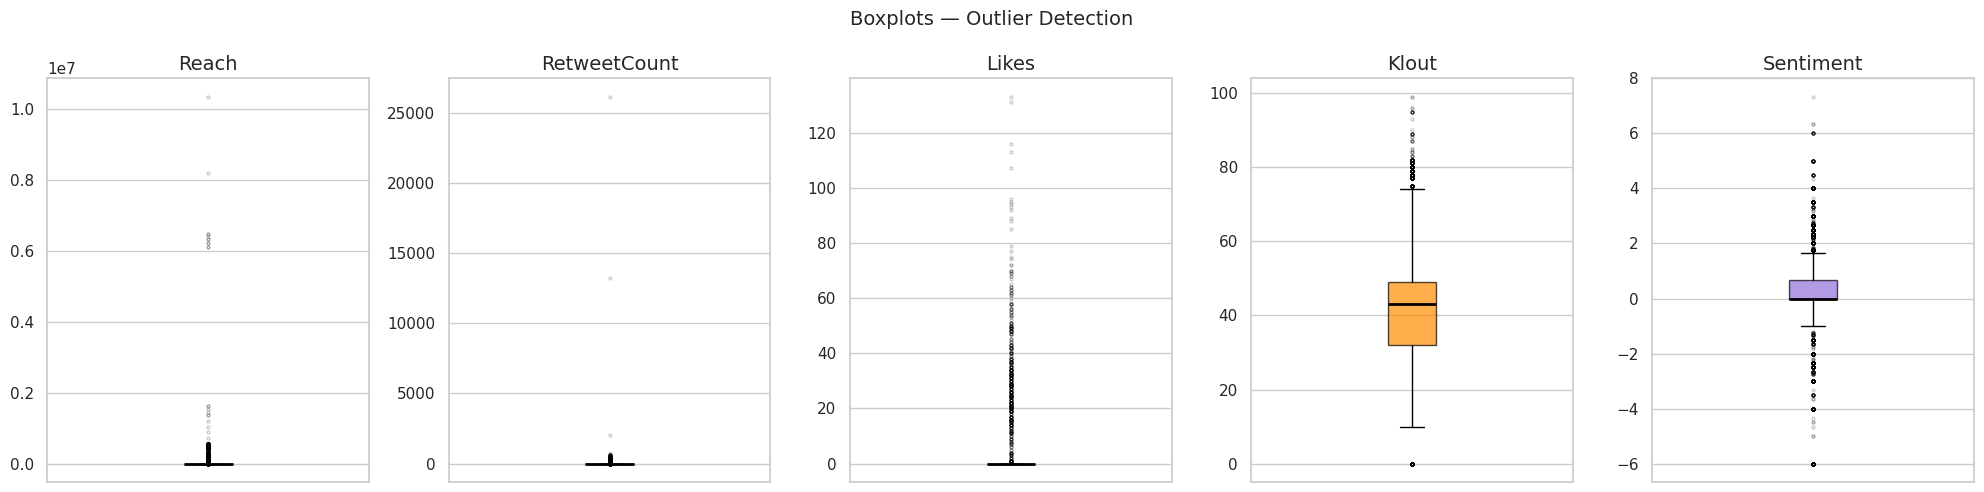

In [10]:
# Boxplots — outlier detection
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
box_vars = [('Reach','steelblue'), ('RetweetCount','tomato'),
            ('Likes','mediumseagreen'), ('Klout','darkorange'), ('Sentiment','mediumpurple')]

for ax, (col, color) in zip(axes, box_vars):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.2))
    ax.set_title(col); ax.set_xticks([])

plt.suptitle('Boxplots — Outlier Detection', fontsize=14)
plt.tight_layout(); plt.show()


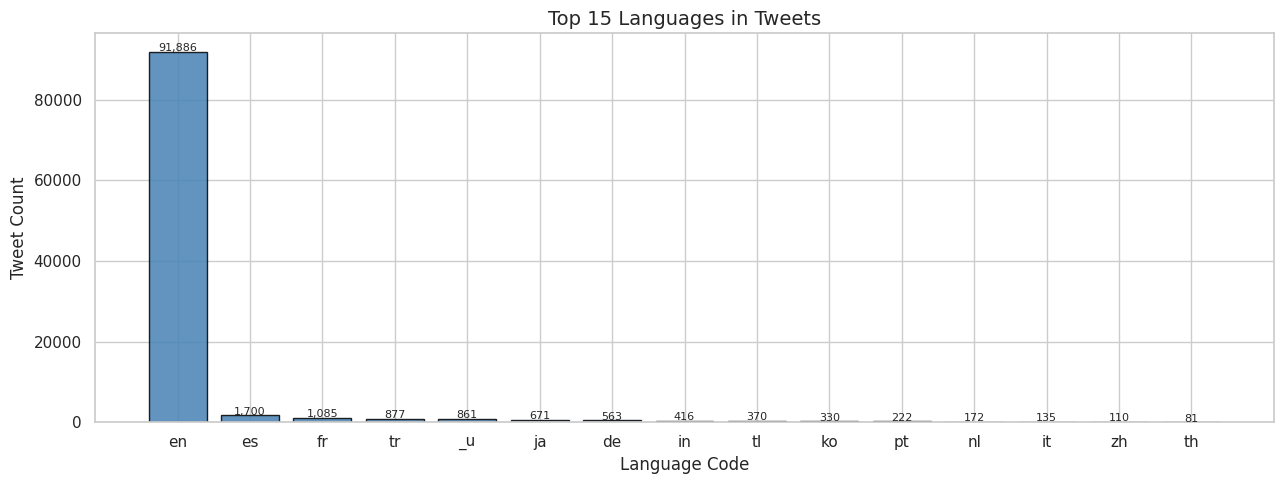

English tweets : 91,886 (91.9%)


In [11]:
# Language distribution — top 15
lang_counts = df['Lang'].value_counts().head(15)

plt.figure(figsize=(13, 5))
bars = plt.bar(lang_counts.index, lang_counts.values, color='steelblue', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, lang_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=8)
plt.title('Top 15 Languages in Tweets')
plt.xlabel('Language Code'); plt.ylabel('Tweet Count')
plt.tight_layout(); plt.show()

print(f'English tweets : {lang_counts.get("en", 0):,} ({lang_counts.get("en",0)/len(df)*100:.1f}%)')


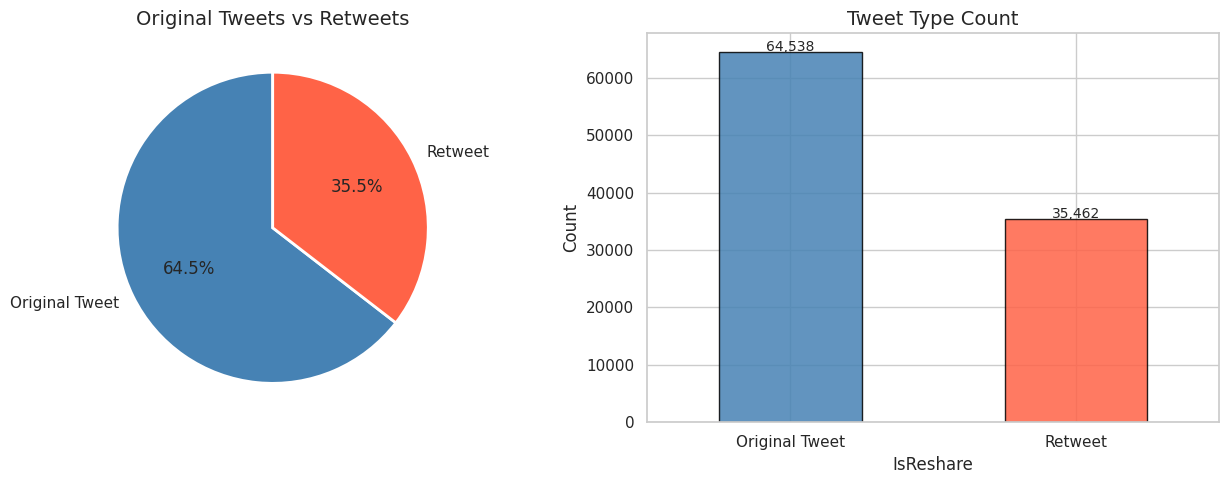

In [12]:
# Original vs Retweet split
reshare_counts = df['IsReshare'].value_counts()
labels = ['Original Tweet', 'Retweet']
colors = ['steelblue', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie(reshare_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Original Tweets vs Retweets')

reshare_counts.plot.bar(ax=axes[1], color=colors, edgecolor='black', alpha=0.85)
axes[1].set_xticklabels(labels, rotation=0)
axes[1].set_title('Tweet Type Count')
axes[1].set_ylabel('Count')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10)

plt.tight_layout(); plt.show()


### 🎯 Practice Time 3.1

1. What percentage of tweets have zero retweets? What does that tell you about virality?
2. The Reach distribution is highly skewed — what does that mean in plain English?
3. Plot the distribution of `Day` (day of month). Is it uniform?


## 4. Engagement Analysis — Reach, Retweets & Likes 🚀 <a id='s4'></a>

### Everyday Example
Not all posts go viral. Most get ignored, a few get shared widely. Let's find out what the engagement landscape looks like.


In [13]:
# ============================================================
# SECTION 4 — Engagement Analysis
# ============================================================
# Engagement percentile breakdown
for col in ['Reach', 'RetweetCount', 'Likes']:
    pcts = df[col].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).round(1)
    print(f'{col} percentiles:')
    print(pcts.to_string()); print()


Reach percentiles:
0.50       448.5
0.75      1496.0
0.90      5307.0
0.95     16540.7
0.99    225068.0

RetweetCount percentiles:
0.50      0.0
0.75      3.0
0.90     16.0
0.95     33.0
0.99    142.0

Likes percentiles:
0.50    0.0
0.75    0.0
0.90    0.0
0.95    0.0
0.99    0.0



In [14]:
# Top 10 most retweeted tweets
top_rt = df.nlargest(10, 'RetweetCount')[['text','RetweetCount','Reach','Likes','Klout','Weekday','Hour']]
print('Top 10 Most Retweeted Tweets:')
for i, row in top_rt.iterrows():
    print(f"  RT={int(row['RetweetCount']):,}  Reach={int(row['Reach']):,}  | {str(row['text'])[:80]}...")
    print()


Top 10 Most Retweeted Tweets:
  RT=26,127  Reach=191  | RT @Chargers: soo hungry need to find my wife and head to pf changs...

  RT=13,195  Reach=386  | RT @2319guy: if I had this set of teeth I wouldn't even bother talking I'd just ...

  RT=2,065  Reach=386  | RT @LifeWithAlcohol: Spring break forecast http://twitter.com/LifeWithAlcohol/st...

  RT=782  Reach=519,252  | Test your iOS Android &amp; web apps against real phones and tablets on AWS. Sta...

  RT=637  Reach=484,724  | Learn how to set up Parse Server on AWS using Elastic Beanstalk. https://cards.t...

  RT=632  Reach=41,423  | RT @planetepics: Barcelona as seen from a helicopter by Tim Orr http://twitter.c...

  RT=620  Reach=447,244  | Follow us for the lastest cloud computing news &amp; updates!...

  RT=616  Reach=139  | RT @awscloud: Learn how to set up Parse Server on AWS using Elastic Beanstalk. h...

  RT=605  Reach=79  | RT @awscloud: Learn how to set up Parse Server on AWS using Elastic Beanstalk. h...

  RT=596

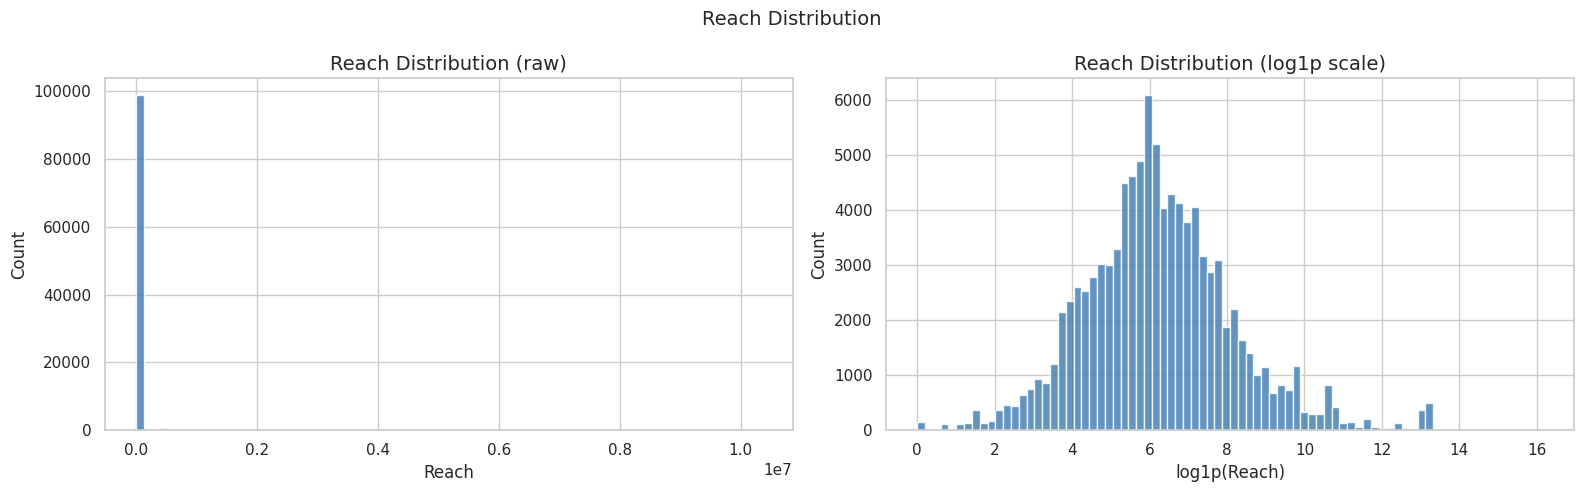

In [15]:
# Reach distribution — log scale histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Raw
axes[0].hist(df['Reach'].dropna(), bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Reach Distribution (raw)')
axes[0].set_xlabel('Reach'); axes[0].set_ylabel('Count')

# Log scale
axes[1].hist(np.log1p(df['Reach'].dropna()), bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Reach Distribution (log1p scale)')
axes[1].set_xlabel('log1p(Reach)'); axes[1].set_ylabel('Count')

plt.suptitle('Reach Distribution', fontsize=14)
plt.tight_layout(); plt.show()


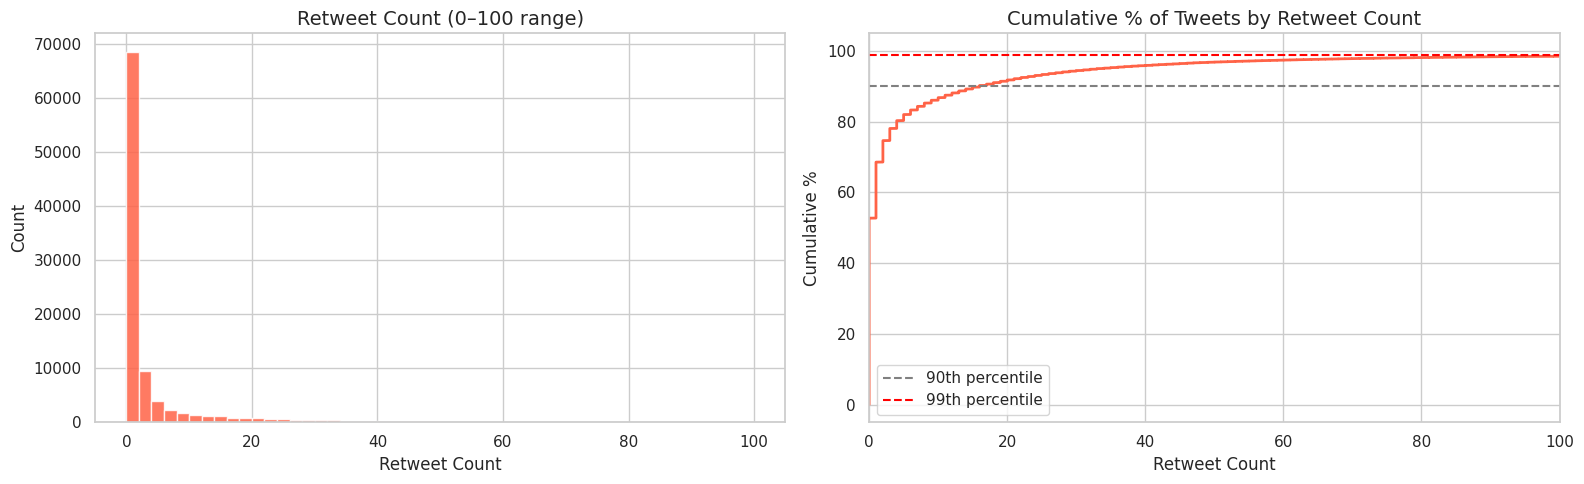

Tweets with 0 retweets : 52,721 (52.7%)
Tweets with >= 10 RT   : 13,937 (13.9%)


In [16]:
# Retweet count distribution — zoom in on 0-100
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

rt_data = df['RetweetCount'].dropna()
axes[0].hist(rt_data[rt_data <= 100], bins=50, color='tomato', edgecolor='white', alpha=0.85)
axes[0].set_title('Retweet Count (0–100 range)')
axes[0].set_xlabel('Retweet Count'); axes[0].set_ylabel('Count')

# Cumulative % of tweets with <= N retweets
rt_sorted = rt_data.sort_values()
cumulative = np.arange(1, len(rt_sorted)+1) / len(rt_sorted) * 100
axes[1].plot(rt_sorted.values, cumulative, color='tomato', linewidth=2)
axes[1].axhline(90, color='gray', linestyle='--', label='90th percentile')
axes[1].axhline(99, color='red', linestyle='--', label='99th percentile')
axes[1].set_xlim(0, 100)
axes[1].set_title('Cumulative % of Tweets by Retweet Count')
axes[1].set_xlabel('Retweet Count'); axes[1].set_ylabel('Cumulative %')
axes[1].legend()

plt.tight_layout(); plt.show()
print(f'Tweets with 0 retweets : {(rt_data == 0).sum():,} ({(rt_data == 0).mean()*100:.1f}%)')
print(f'Tweets with >= 10 RT   : {(rt_data >= 10).sum():,} ({(rt_data >= 10).mean()*100:.1f}%)')


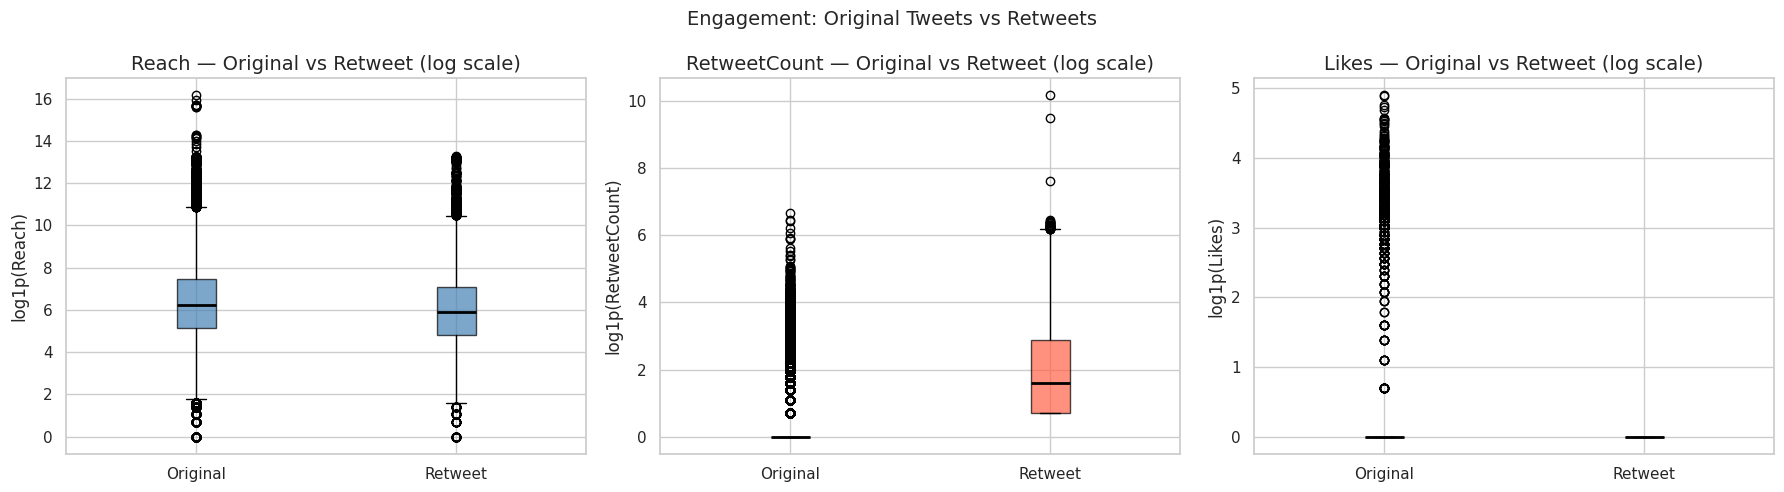

In [17]:
# Engagement by Original vs Retweet
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('Reach','steelblue'), ('RetweetCount','tomato'), ('Likes','mediumseagreen')]

for ax, (col, color) in zip(axes, metrics):
    orig = df[df['IsReshare']==False][col].dropna()
    rt   = df[df['IsReshare']==True][col].dropna()
    ax.boxplot([np.log1p(orig), np.log1p(rt)],
               labels=['Original','Retweet'], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'{col} — Original vs Retweet (log scale)')
    ax.set_ylabel(f'log1p({col})')

plt.suptitle('Engagement: Original Tweets vs Retweets', fontsize=14)
plt.tight_layout(); plt.show()


## 5. Temporal Analysis — Hour, Day & Weekday ⏰ <a id='s5'></a>

### Everyday Example
Posting at 3am gets fewer eyes than posting at 9am. Let's find the best times to tweet for maximum reach.


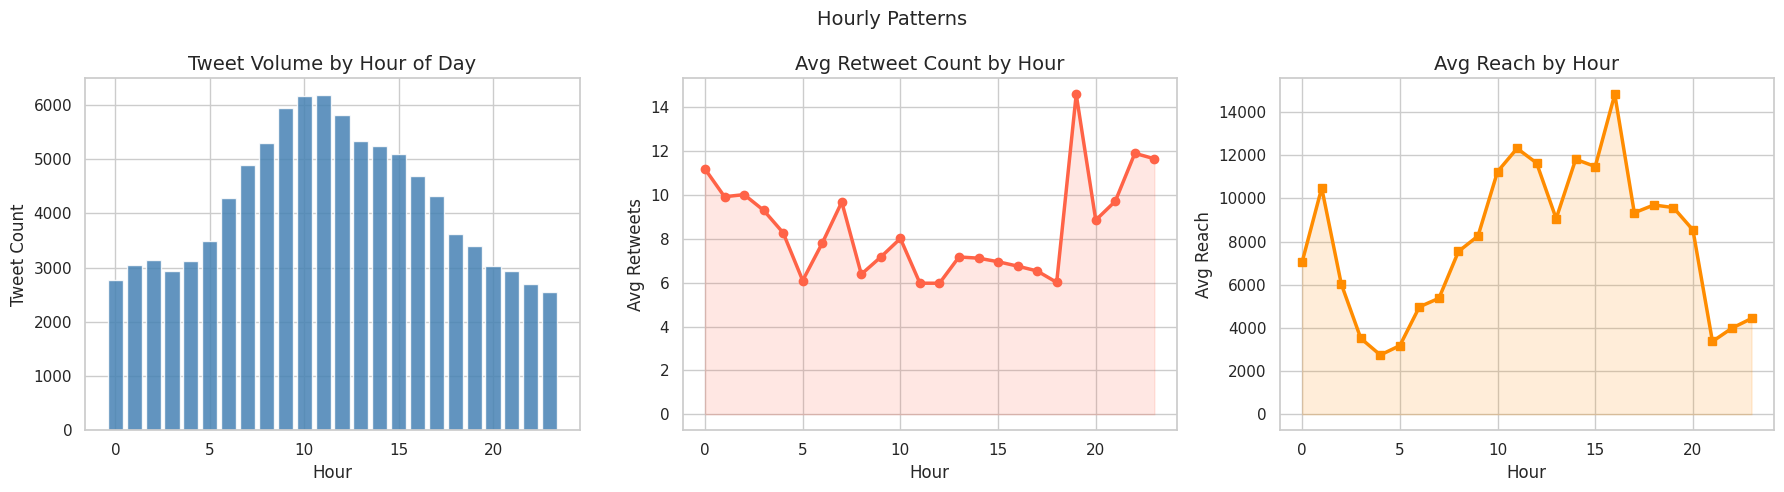

In [18]:
# ============================================================
# SECTION 5 — Temporal Analysis
# ============================================================
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Tweet volume by hour
hourly_vol = df.groupby('Hour').size()
hourly_rt  = df.groupby('Hour')['RetweetCount'].mean()
hourly_reach = df.groupby('Hour')['Reach'].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(hourly_vol.index, hourly_vol.values, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Tweet Volume by Hour of Day')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Tweet Count')

axes[1].plot(hourly_rt.index, hourly_rt.values, marker='o', color='tomato', linewidth=2.5)
axes[1].fill_between(hourly_rt.index, hourly_rt.values, alpha=0.15, color='tomato')
axes[1].set_title('Avg Retweet Count by Hour')
axes[1].set_xlabel('Hour'); axes[1].set_ylabel('Avg Retweets')

axes[2].plot(hourly_reach.index, hourly_reach.values, marker='s', color='darkorange', linewidth=2.5)
axes[2].fill_between(hourly_reach.index, hourly_reach.values, alpha=0.15, color='darkorange')
axes[2].set_title('Avg Reach by Hour')
axes[2].set_xlabel('Hour'); axes[2].set_ylabel('Avg Reach')

plt.suptitle('Hourly Patterns', fontsize=14)
plt.tight_layout(); plt.show()


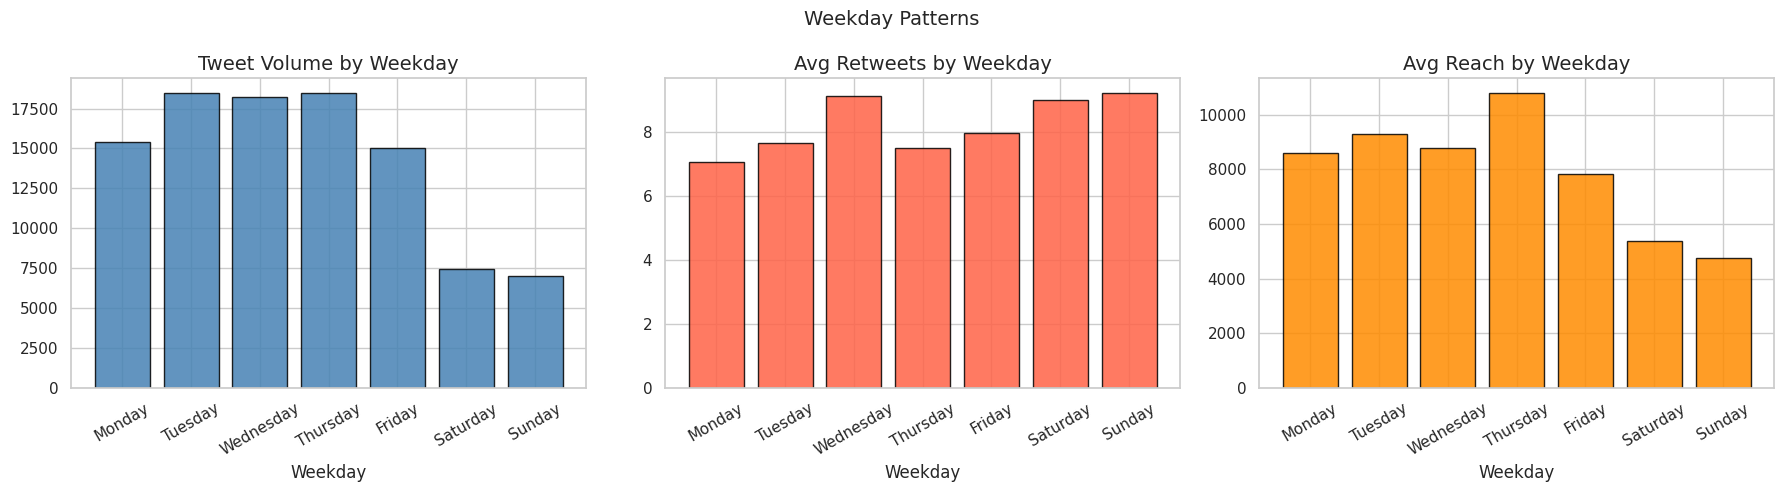

In [19]:
# Tweet volume and engagement by weekday
weekday_vol   = df.groupby('Weekday').size().reindex(weekday_order)
weekday_rt    = df.groupby('Weekday')['RetweetCount'].mean().reindex(weekday_order)
weekday_reach = df.groupby('Weekday')['Reach'].mean().reindex(weekday_order)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['steelblue','tomato','darkorange']

for ax, data, title, color in zip(axes,
    [weekday_vol, weekday_rt, weekday_reach],
    ['Tweet Volume by Weekday', 'Avg Retweets by Weekday', 'Avg Reach by Weekday'],
    colors):
    ax.bar(data.index, data.values, color=color, edgecolor='black', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Weekday')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Weekday Patterns', fontsize=14)
plt.tight_layout(); plt.show()


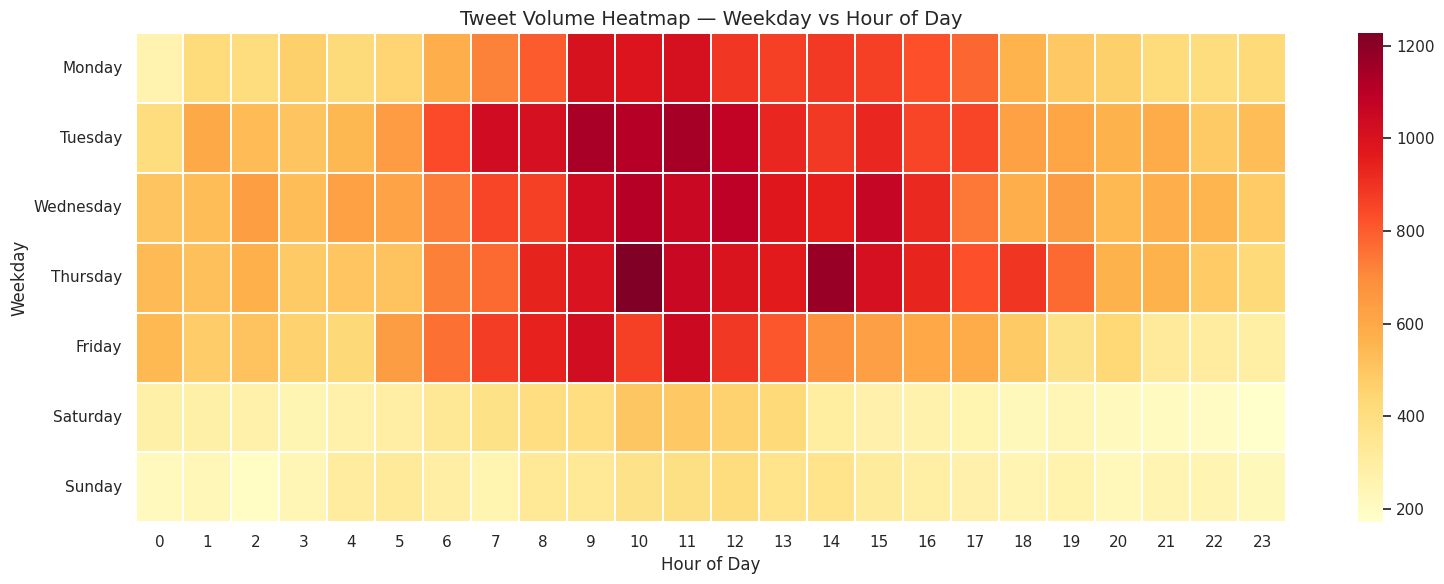

In [20]:
# Heatmap: Hour x Weekday — Tweet Volume
pivot_vol = df.groupby(['Weekday','Hour']).size().unstack(fill_value=0).reindex(weekday_order)

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_vol, cmap='YlOrRd', linewidths=0.3,
            annot=False, fmt='d')
plt.title('Tweet Volume Heatmap — Weekday vs Hour of Day')
plt.xlabel('Hour of Day'); plt.ylabel('Weekday')
plt.tight_layout(); plt.show()


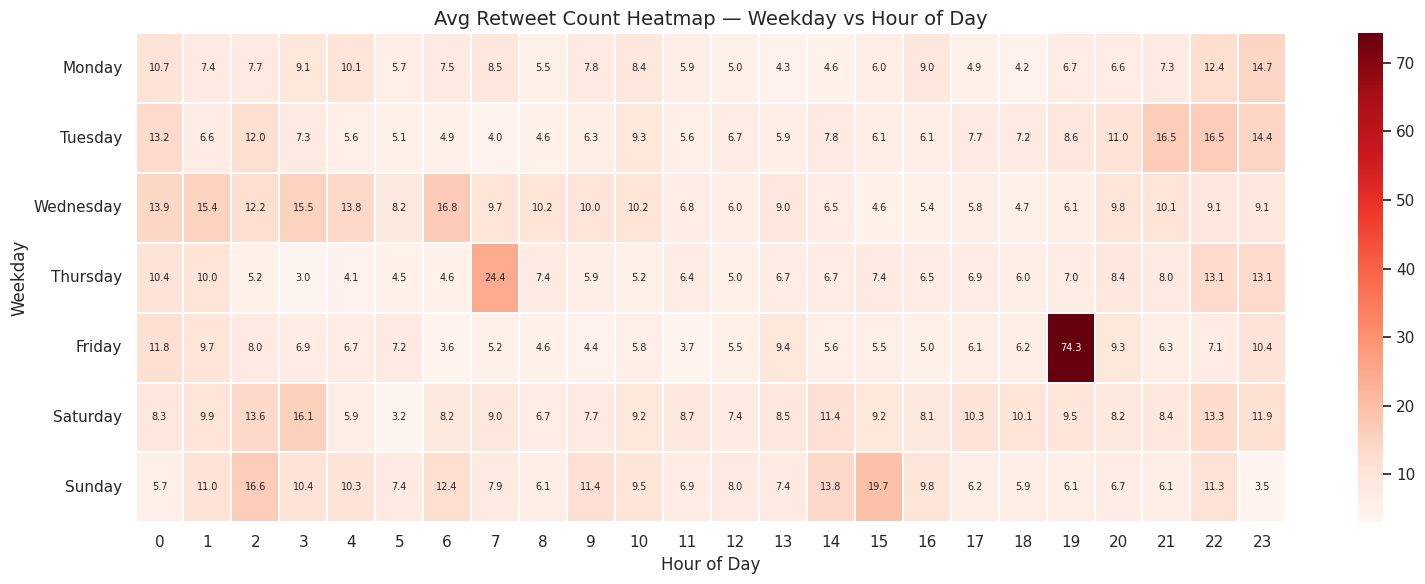

Best hour for retweets  : 19:00
Best weekday for retweets: Sunday


In [21]:
# Heatmap: Hour x Weekday — Avg Retweet Count
pivot_rt = df.groupby(['Weekday','Hour'])['RetweetCount'].mean().unstack(fill_value=0).reindex(weekday_order)

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_rt, cmap='Reds', linewidths=0.3,
            annot=True, fmt='.1f', annot_kws={'size': 7})
plt.title('Avg Retweet Count Heatmap — Weekday vs Hour of Day')
plt.xlabel('Hour of Day'); plt.ylabel('Weekday')
plt.tight_layout(); plt.show()

best_hour = hourly_rt.idxmax()
best_day  = weekday_rt.idxmax()
print(f'Best hour for retweets  : {int(best_hour):02d}:00')
print(f'Best weekday for retweets: {best_day}')


### 🎯 Practice Time 5.1

1. At what hour of the day are tweets most likely to be retweeted?
2. Does tweeting on weekends result in higher or lower reach than weekdays?
3. Create a heatmap for average `Reach` by Weekday × Hour.


## 6. Language & Geographic Analysis 🌍 <a id='s6'></a>

### Everyday Example
A global brand needs to know which languages its audience speaks. Let's see how multilingual this Twitter conversation is.


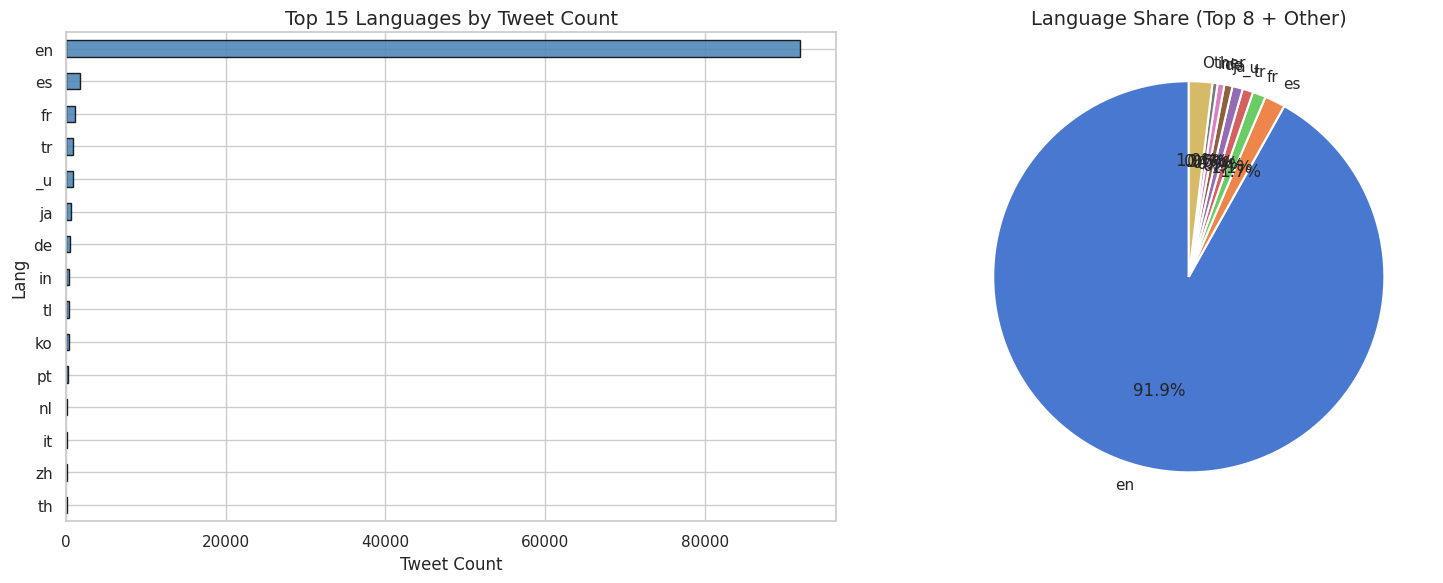

In [22]:
# ============================================================
# SECTION 6 — Language Analysis
# ============================================================
lang_counts = df['Lang'].value_counts()
top15_lang  = lang_counts.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart top 15
top15_lang.sort_values().plot.barh(ax=axes[0], color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Languages by Tweet Count')
axes[0].set_xlabel('Tweet Count')

# Pie chart top 8 + Other
top8 = lang_counts.head(8)
other = lang_counts.iloc[8:].sum()
pie_data   = list(top8.values) + [other]
pie_labels = list(top8.index)  + ['Other']
axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Language Share (Top 8 + Other)')

plt.tight_layout(); plt.show()


Engagement by Language (Top 10):
      Avg_Reach  Avg_Retweets  Avg_Klout  Tweet_Count
Lang                                                 
en       8620.8           8.6       40.5        91886
es       2744.0           1.9       39.2         1700
fr       6771.3           1.9       42.2         1085
tr      36343.2           0.0       45.2          877
_u       8528.9           0.9       37.1          861
ja       1485.5           1.3       38.2          671
de       4662.2           0.9       40.7          563
in       2302.0           1.5       32.2          416
tl        450.2           1.6       31.0          370
ko       5310.5           4.0       30.3          330


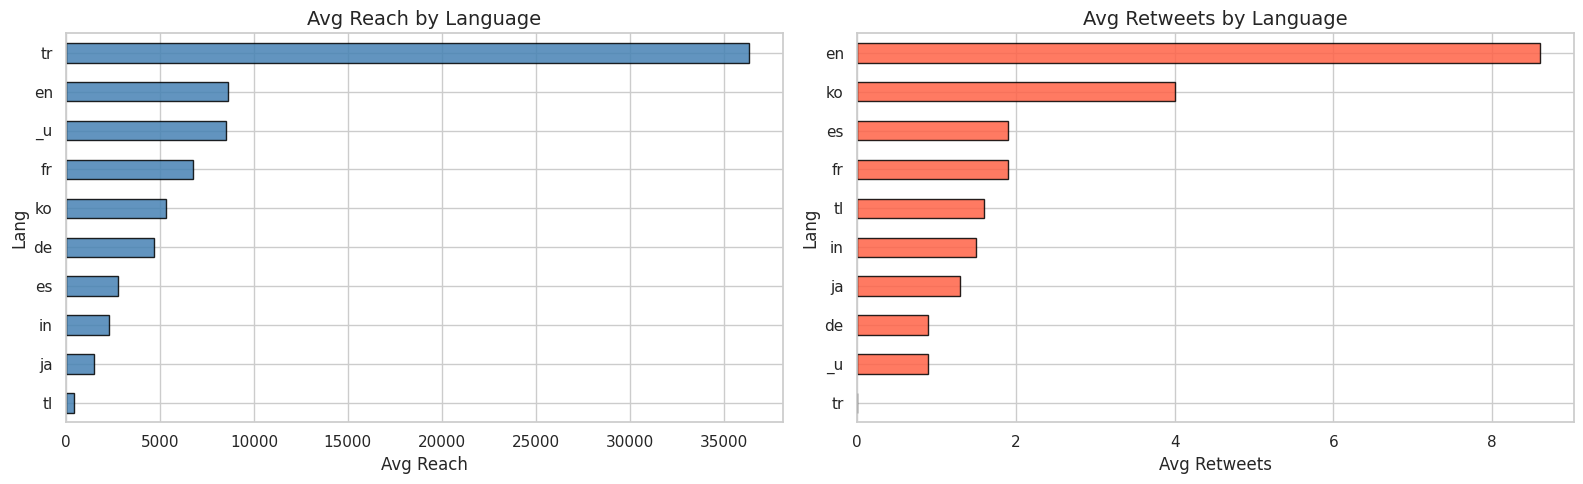

In [23]:
# Engagement by language — top 10 languages
top10_langs = lang_counts.head(10).index.tolist()
lang_eng = df[df['Lang'].isin(top10_langs)].groupby('Lang').agg(
    Avg_Reach=('Reach','mean'),
    Avg_Retweets=('RetweetCount','mean'),
    Avg_Klout=('Klout','mean'),
    Tweet_Count=('TweetID','count')
).reindex(top10_langs).round(1)

print('Engagement by Language (Top 10):')
print(lang_eng.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
lang_eng['Avg_Reach'].sort_values().plot.barh(ax=axes[0], color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Avg Reach by Language')
axes[0].set_xlabel('Avg Reach')

lang_eng['Avg_Retweets'].sort_values().plot.barh(ax=axes[1], color='tomato', edgecolor='black', alpha=0.85)
axes[1].set_title('Avg Retweets by Language')
axes[1].set_xlabel('Avg Retweets')

plt.tight_layout(); plt.show()


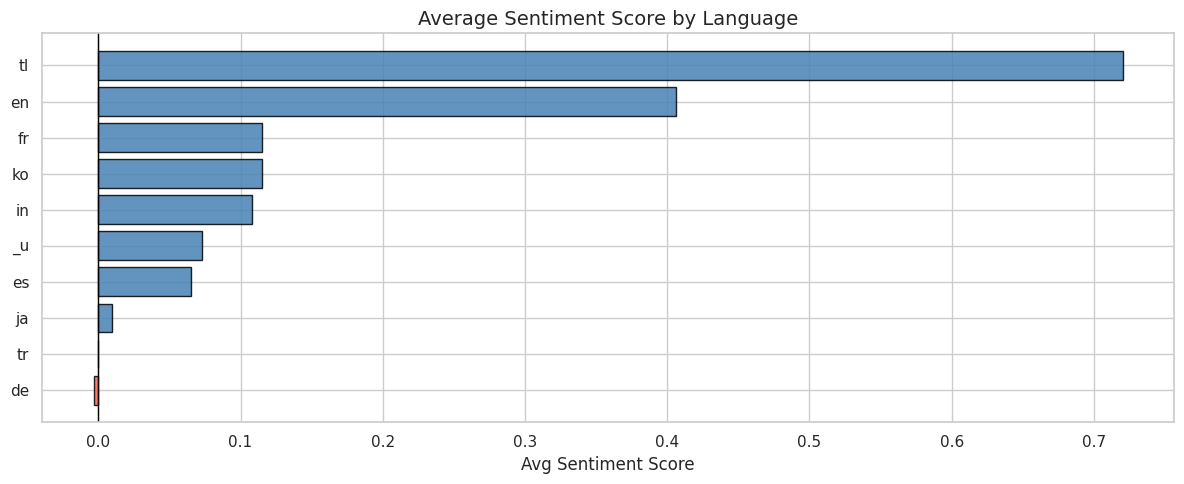

In [24]:
# Sentiment by language
lang_sent = df[df['Lang'].isin(top10_langs)].groupby('Lang')['Sentiment'].mean().sort_values()

plt.figure(figsize=(12, 5))
colors_sent = ['tomato' if v < 0 else 'steelblue' for v in lang_sent.values]
plt.barh(lang_sent.index, lang_sent.values, color=colors_sent, edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', linewidth=1)
plt.title('Average Sentiment Score by Language')
plt.xlabel('Avg Sentiment Score')
plt.tight_layout(); plt.show()


## 7. Sentiment Analysis 😊😐😠 <a id='s7'></a>

### Everyday Example
Reading a product review, you instantly sense if it's positive or negative. Sentiment scores do this automatically at scale.

**Sentiment Score Guide:**
- Score > 0 → Positive tweet
- Score = 0 → Neutral tweet
- Score < 0 → Negative tweet


In [25]:
# ============================================================
# SECTION 7 — Sentiment Analysis
# ============================================================
# Categorise sentiment
def sentiment_label(s):
    if s > 0:   return 'Positive'
    elif s < 0: return 'Negative'
    else:       return 'Neutral'

df['SentimentLabel'] = df['Sentiment'].apply(sentiment_label)
sent_counts = df['SentimentLabel'].value_counts()
print('Sentiment breakdown:')
print(sent_counts.to_string())
print(f'\nPositive %: {sent_counts.get("Positive",0)/len(df)*100:.1f}%')
print(f'Neutral  %: {sent_counts.get("Neutral",0)/len(df)*100:.1f}%')
print(f'Negative %: {sent_counts.get("Negative",0)/len(df)*100:.1f}%')


Sentiment breakdown:
SentimentLabel
Neutral     67424
Positive    27024
Negative     5552

Positive %: 27.0%
Neutral  %: 67.4%
Negative %: 5.6%


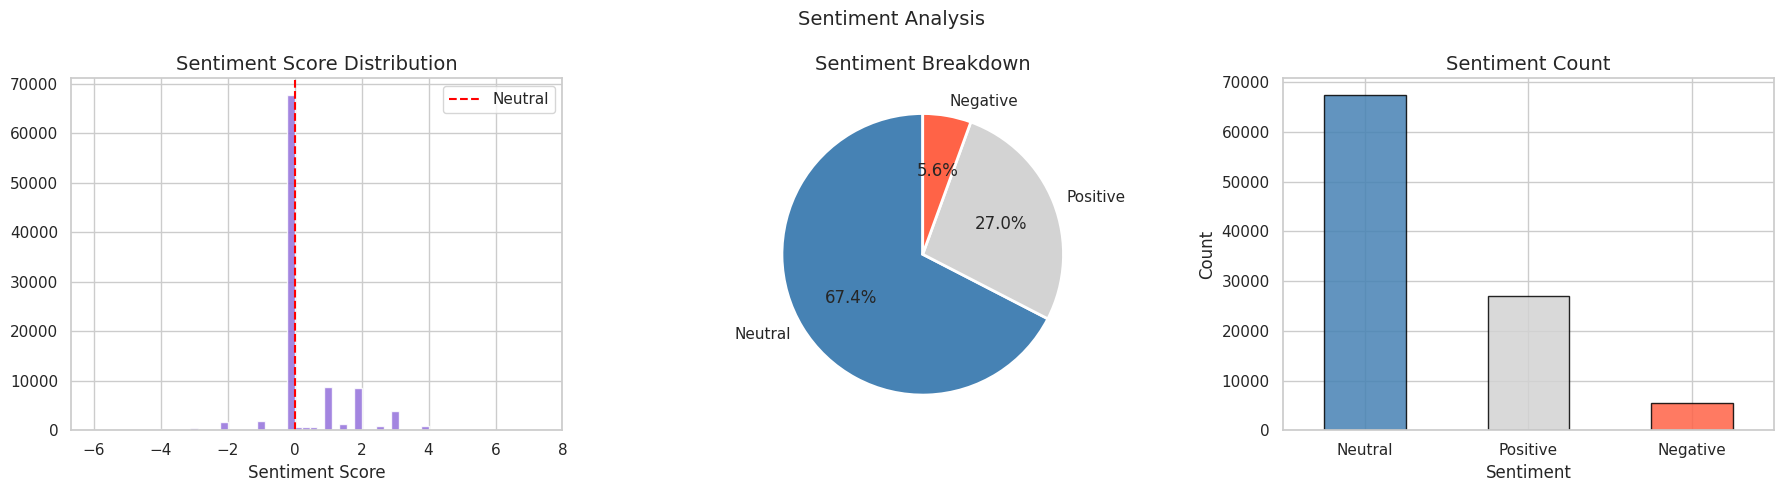

In [26]:
# Sentiment distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of raw sentiment scores
axes[0].hist(df['Sentiment'].dropna(), bins=60, color='mediumpurple',
             edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Neutral')
axes[0].set_title('Sentiment Score Distribution')
axes[0].set_xlabel('Sentiment Score'); axes[0].legend()

# Pie chart
colors_pie = ['steelblue','lightgray','tomato']
axes[1].pie(sent_counts.values, labels=sent_counts.index,
            colors=colors_pie, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Sentiment Breakdown')

# Bar chart
sent_counts.plot.bar(ax=axes[2], color=colors_pie, edgecolor='black', alpha=0.85)
axes[2].set_title('Sentiment Count')
axes[2].set_xlabel('Sentiment'); axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Sentiment Analysis', fontsize=14)
plt.tight_layout(); plt.show()


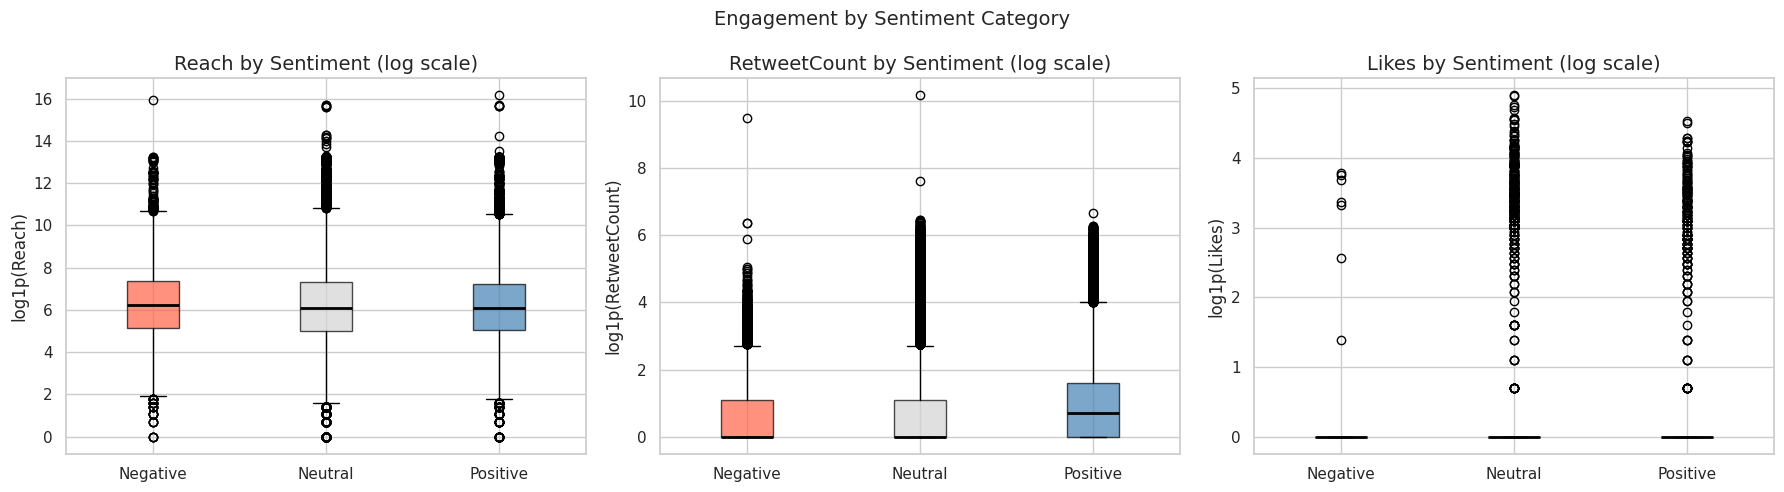

In [27]:
# Sentiment vs Engagement
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
order = ['Negative','Neutral','Positive']
palette = {'Negative':'tomato','Neutral':'lightgray','Positive':'steelblue'}

for ax, col in zip(axes, ['Reach','RetweetCount','Likes']):
    data_by_sent = [np.log1p(df[df['SentimentLabel']==s][col].dropna()) for s in order]
    bp = ax.boxplot(data_by_sent, labels=order, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, s in zip(bp['boxes'], order):
        patch.set_facecolor(palette[s])
        patch.set_alpha(0.7)
    ax.set_title(f'{col} by Sentiment (log scale)')
    ax.set_ylabel(f'log1p({col})')

plt.suptitle('Engagement by Sentiment Category', fontsize=14)
plt.tight_layout(); plt.show()


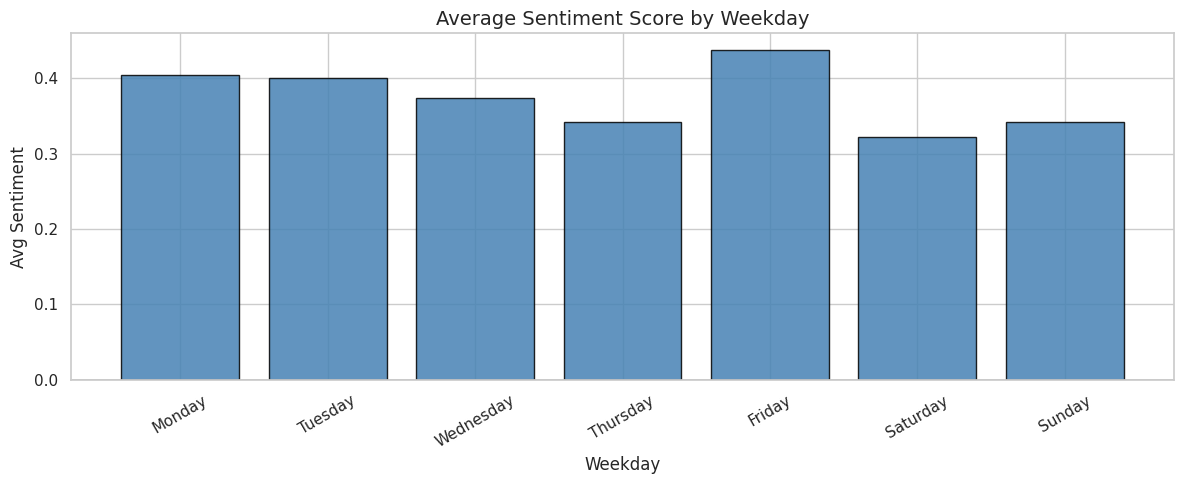

In [28]:
# Sentiment by weekday
sent_by_day = df.groupby('Weekday')['Sentiment'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(12, 5))
colors_day = ['tomato' if v < 0 else 'steelblue' for v in sent_by_day.values]
plt.bar(sent_by_day.index, sent_by_day.values, color=colors_day, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', linewidth=1)
plt.title('Average Sentiment Score by Weekday')
plt.xlabel('Weekday'); plt.ylabel('Avg Sentiment')
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()


In [29]:
# Most positive and most negative tweets
print('=== TOP 5 MOST POSITIVE TWEETS ===')
for _, row in df.nlargest(5, 'Sentiment').iterrows():
    print(f"  Score={row['Sentiment']:.2f} | {str(row['text'])[:100]}...")
    print()

print('=== TOP 5 MOST NEGATIVE TWEETS ===')
for _, row in df.nsmallest(5, 'Sentiment').iterrows():
    print(f"  Score={row['Sentiment']:.2f} | {str(row['text'])[:100]}...")
    print()


=== TOP 5 MOST POSITIVE TWEETS ===
  Score=7.33 | It's amazing Netflix has moved entirely to AWS but more amazing that Amazon can scale better than al...

  Score=6.33 | Exciting times at @OneCloudSW.  Thrilled to have Mike Thompson join as we move into hyper-growth #hy...

  Score=6.33 | RT @mcrespi8381: Exciting times at @OneCloudSW.  Thrilled to have Mike Thompson join as we move into...

  Score=6.00 | @ganapatigmb AWS is so damn awesome. Doesn't get nearly as much credit as it deserves....

  Score=6.00 | @stevie_chambers @pivotal Slack Apple AWS most mobile apps etc are all fucking awesome without check...

=== TOP 5 MOST NEGATIVE TWEETS ===
  Score=-6.00 | IT news: The AWS Java documentation is fucking ridiculous https://areallygoodrantblog.wordpress.com/...

  Score=-6.00 | The AWS Java documentation is fucking ridiculous https://areallygoodrantblog.wordpress.com/2016/02/1...

  Score=-6.00 | The AWS Java documentation is fucking ridiculous: Comments https://areallygoodrantblog

### 🎯 Practice Time 7.1

1. What percentage of tweets are strictly neutral (score = 0)?
2. Do retweets tend to have higher or lower sentiment than original tweets?
3. Plot sentiment score distribution separately for English vs Spanish tweets.


## 8. Influencer & Klout Analysis ⭐ <a id='s8'></a>

### Everyday Example
A celebrity's tweet reaches millions; a regular user's reaches hundreds. The Klout score (0–100) measures a user's social media influence. Let's see how it shapes engagement.


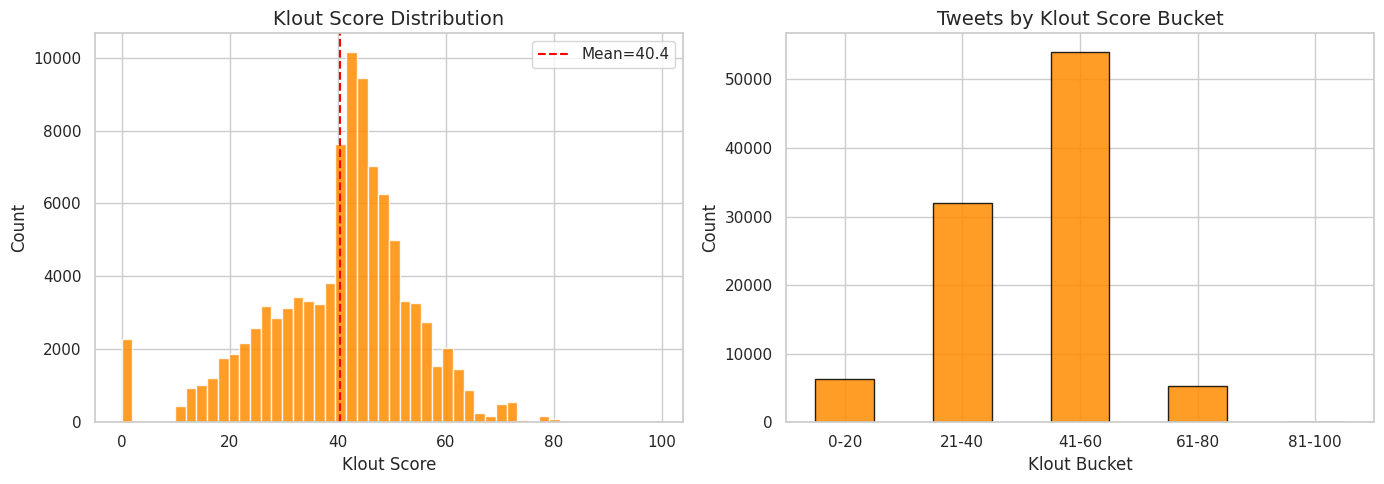

In [30]:
# ============================================================
# SECTION 8 — Klout / Influencer Analysis
# ============================================================
# Klout score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Klout'].dropna().hist(bins=50, ax=axes[0], color='darkorange', edgecolor='white', alpha=0.85)
axes[0].set_title('Klout Score Distribution')
axes[0].set_xlabel('Klout Score'); axes[0].set_ylabel('Count')
axes[0].axvline(df['Klout'].mean(), color='red', linestyle='--',
                label=f'Mean={df["Klout"].mean():.1f}')
axes[0].legend()

# Klout buckets
df['KloutBucket'] = pd.cut(df['Klout'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20','21-40','41-60','61-80','81-100'])
klout_counts = df['KloutBucket'].value_counts().sort_index()
klout_counts.plot.bar(ax=axes[1], color='darkorange', edgecolor='black', alpha=0.85)
axes[1].set_title('Tweets by Klout Score Bucket')
axes[1].set_xlabel('Klout Bucket'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()


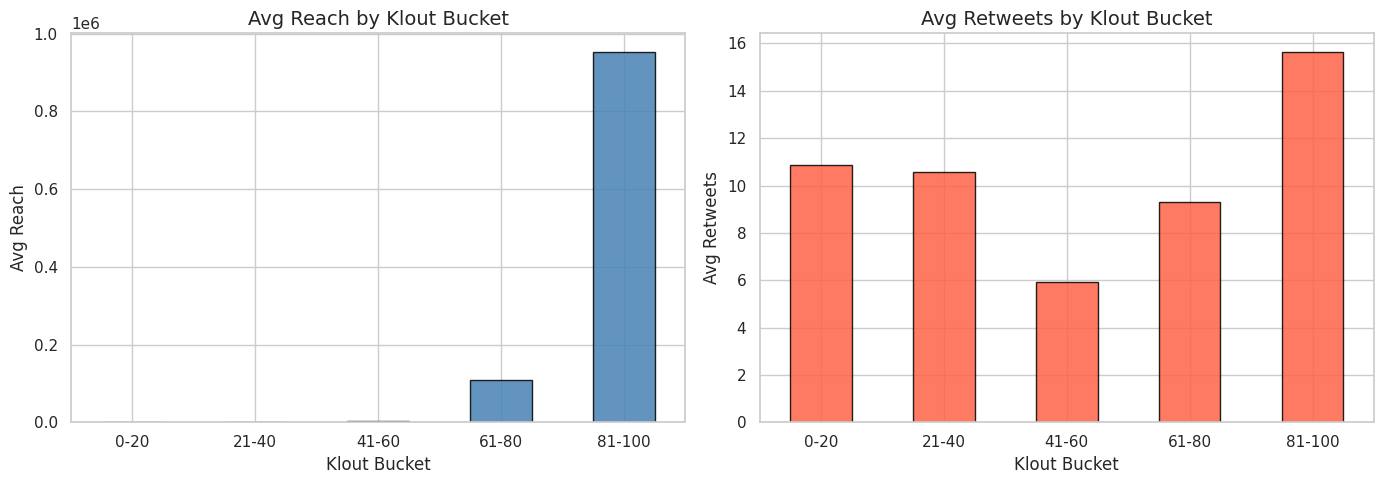

In [31]:
# Reach and Retweets by Klout bucket
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

klout_reach = df.groupby('KloutBucket')['Reach'].mean()
klout_rt    = df.groupby('KloutBucket')['RetweetCount'].mean()

klout_reach.plot.bar(ax=axes[0], color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Avg Reach by Klout Bucket')
axes[0].set_xlabel('Klout Bucket'); axes[0].set_ylabel('Avg Reach')
axes[0].tick_params(axis='x', rotation=0)

klout_rt.plot.bar(ax=axes[1], color='tomato', edgecolor='black', alpha=0.85)
axes[1].set_title('Avg Retweets by Klout Bucket')
axes[1].set_xlabel('Klout Bucket'); axes[1].set_ylabel('Avg Retweets')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()


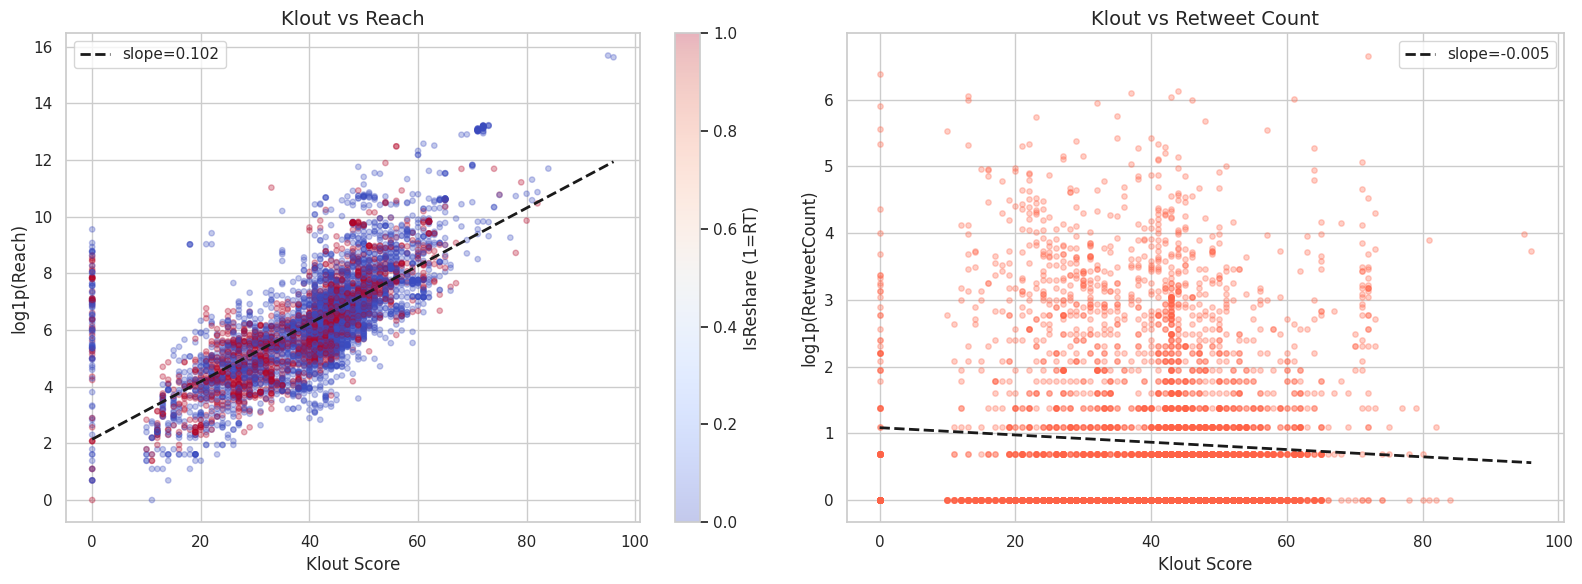

In [32]:
# Scatter: Klout vs Reach (sample 5000 for clarity)
sample = df[['Klout','Reach','RetweetCount','IsReshare']].dropna().sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(sample['Klout'], np.log1p(sample['Reach']),
                     c=sample['IsReshare'].astype(int), cmap='coolwarm',
                     alpha=0.3, s=15)
plt.colorbar(sc, ax=axes[0], label='IsReshare (1=RT)')
m, b = np.polyfit(sample['Klout'], np.log1p(sample['Reach']), 1)
x = np.linspace(sample['Klout'].min(), sample['Klout'].max(), 100)
axes[0].plot(x, m*x+b, 'k--', lw=2, label=f'slope={m:.3f}')
axes[0].set_xlabel('Klout Score'); axes[0].set_ylabel('log1p(Reach)')
axes[0].set_title('Klout vs Reach'); axes[0].legend()

axes[1].scatter(sample['Klout'], np.log1p(sample['RetweetCount']),
                alpha=0.3, color='tomato', s=15)
m2, b2 = np.polyfit(sample['Klout'], np.log1p(sample['RetweetCount']), 1)
axes[1].plot(x, m2*x+b2, 'k--', lw=2, label=f'slope={m2:.3f}')
axes[1].set_xlabel('Klout Score'); axes[1].set_ylabel('log1p(RetweetCount)')
axes[1].set_title('Klout vs Retweet Count'); axes[1].legend()

plt.tight_layout(); plt.show()


## 9. Correlation & Bivariate Analysis 🔗 <a id='s9'></a>

### Everyday Example
Does a higher Klout score always mean more retweets? Does positive sentiment drive more likes? We check which variables move together.


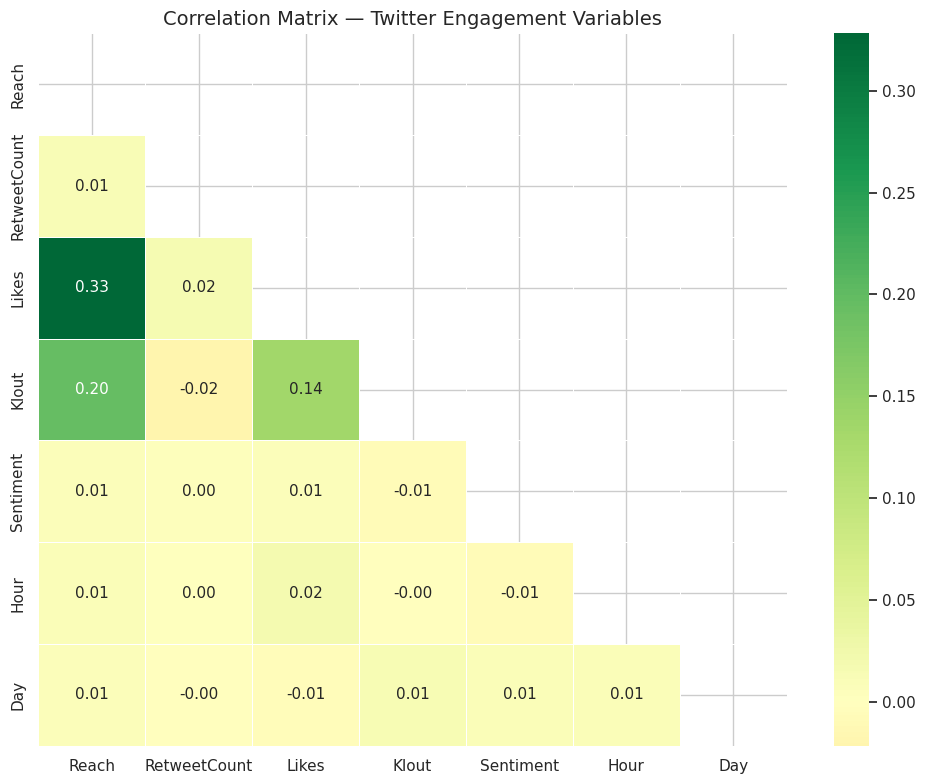

Top correlations with RetweetCount:
Likes        0.017383
Reach        0.013427
Sentiment    0.004717
Hour         0.001740
Day         -0.001252
Klout       -0.021488


In [33]:
# ============================================================
# SECTION 9 — Correlation Analysis
# ============================================================
corr_cols = ['Reach','RetweetCount','Likes','Klout','Sentiment','Hour','Day']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 11})
plt.title('Correlation Matrix — Twitter Engagement Variables', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with RetweetCount:')
print(corr['RetweetCount'].drop('RetweetCount').sort_values(ascending=False).to_string())


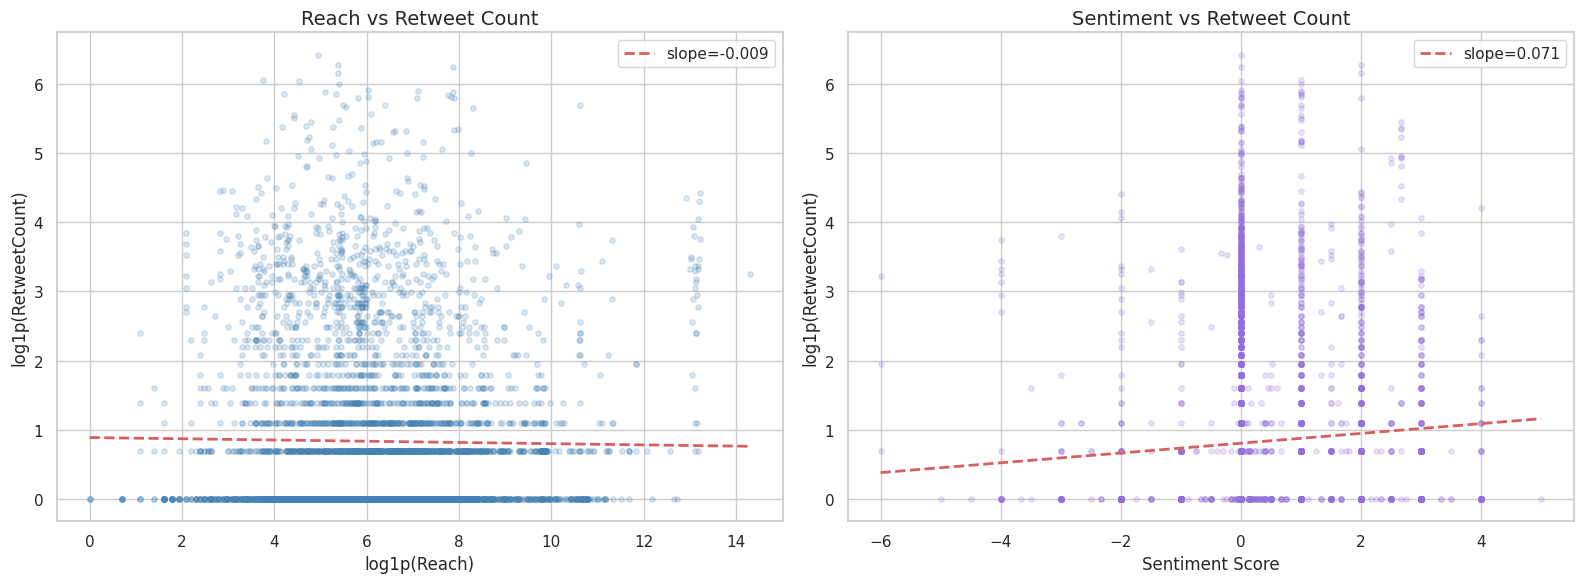

In [34]:
# Scatter: Reach vs RetweetCount
sample2 = df[['Reach','RetweetCount','Klout','Sentiment']].dropna().sample(5000, random_state=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(np.log1p(sample2['Reach']), np.log1p(sample2['RetweetCount']),
                alpha=0.2, color='steelblue', s=15)
m, b = np.polyfit(np.log1p(sample2['Reach']), np.log1p(sample2['RetweetCount']), 1)
x = np.linspace(0, np.log1p(sample2['Reach']).max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'slope={m:.3f}')
axes[0].set_xlabel('log1p(Reach)'); axes[0].set_ylabel('log1p(RetweetCount)')
axes[0].set_title('Reach vs Retweet Count'); axes[0].legend()

axes[1].scatter(sample2['Sentiment'], np.log1p(sample2['RetweetCount']),
                alpha=0.2, color='mediumpurple', s=15)
m2, b2 = np.polyfit(sample2['Sentiment'], np.log1p(sample2['RetweetCount']), 1)
x2 = np.linspace(sample2['Sentiment'].min(), sample2['Sentiment'].max(), 100)
axes[1].plot(x2, m2*x2+b2, 'r--', lw=2, label=f'slope={m2:.3f}')
axes[1].set_xlabel('Sentiment Score'); axes[1].set_ylabel('log1p(RetweetCount)')
axes[1].set_title('Sentiment vs Retweet Count'); axes[1].legend()

plt.tight_layout(); plt.show()


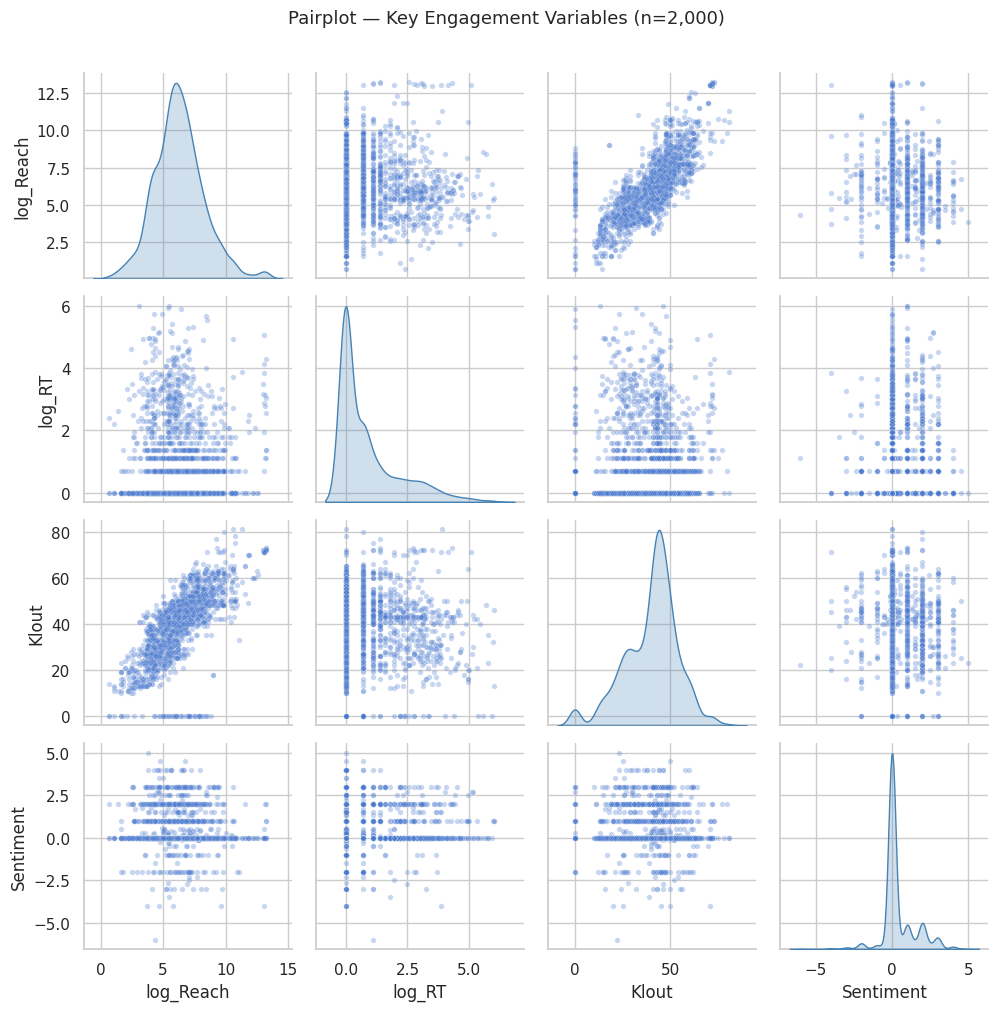

In [35]:
# Pairplot — sample for speed
pair_sample = df[['Reach','RetweetCount','Klout','Sentiment']].dropna().sample(2000, random_state=42)
pair_sample['log_Reach'] = np.log1p(pair_sample['Reach'])
pair_sample['log_RT']    = np.log1p(pair_sample['RetweetCount'])

sns.pairplot(pair_sample[['log_Reach','log_RT','Klout','Sentiment']],
             diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15},
             diag_kws={'color': 'steelblue'})
plt.suptitle('Pairplot — Key Engagement Variables (n=2,000)', y=1.01, fontsize=13)
plt.tight_layout(); plt.show()


## 10. Statistical Hypothesis Testing 🧪 <a id='s10'></a>

We test four hypotheses using standard statistical tests (α = 0.05).

| # | Hypothesis | Test |
|---|---|---|
| H1 | Retweets have significantly higher Reach than original tweets | Independent t-test |
| H2 | Higher Klout score is positively correlated with Reach | Pearson correlation |
| H3 | Positive sentiment tweets get significantly more retweets than negative ones | Independent t-test |
| H4 | Reach is significantly different across weekdays | One-way ANOVA |


H1: Reach — Retweets vs Original Tweets
  Retweet mean Reach  = 3,354.9
  Original mean Reach = 11,392.8
  t-statistic = -17.9768,  p-value = 0.000000
  RESULT: REJECT H0 — Retweets have significantly different Reach than originals.


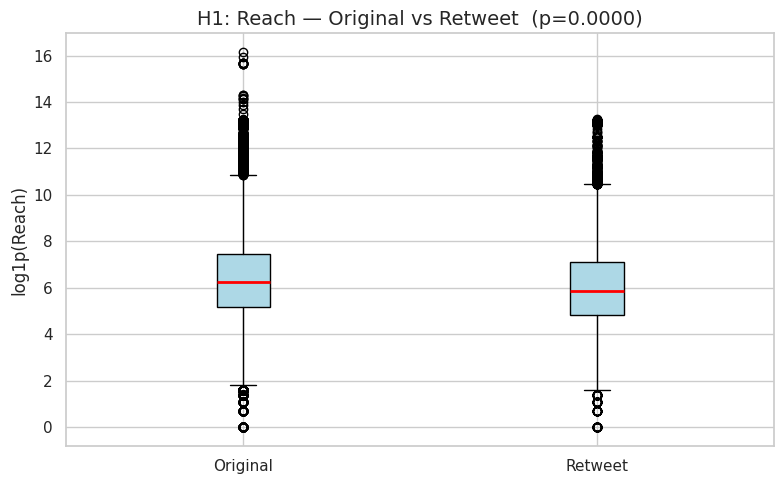

In [36]:
# ============================================================
# SECTION 10 — Hypothesis Testing
# ============================================================

# H1: Reach — Retweets vs Original tweets
rt_reach   = df[df['IsReshare']==True]['Reach'].dropna()
orig_reach = df[df['IsReshare']==False]['Reach'].dropna()
t1, p1 = stats.ttest_ind(rt_reach, orig_reach, equal_var=False)

print('H1: Reach — Retweets vs Original Tweets')
print(f'  Retweet mean Reach  = {rt_reach.mean():,.1f}')
print(f'  Original mean Reach = {orig_reach.mean():,.1f}')
print(f'  t-statistic = {t1:.4f},  p-value = {p1:.6f}')
result1 = 'REJECT H0 — Retweets have significantly different Reach than originals.' if p1 < 0.05 else 'FAIL TO REJECT H0.'
print(f'  RESULT: {result1}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([np.log1p(orig_reach), np.log1p(rt_reach)],
           labels=['Original','Retweet'], patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('log1p(Reach)')
ax.set_title(f'H1: Reach — Original vs Retweet  (p={p1:.4f})')
plt.tight_layout(); plt.show()


H2: Klout Score vs Reach (log scale)
  Pearson r = 0.7226,  p-value = 0.000000
  RESULT: REJECT H0 — Significant positive correlation (r=0.723). Higher Klout = higher Reach.


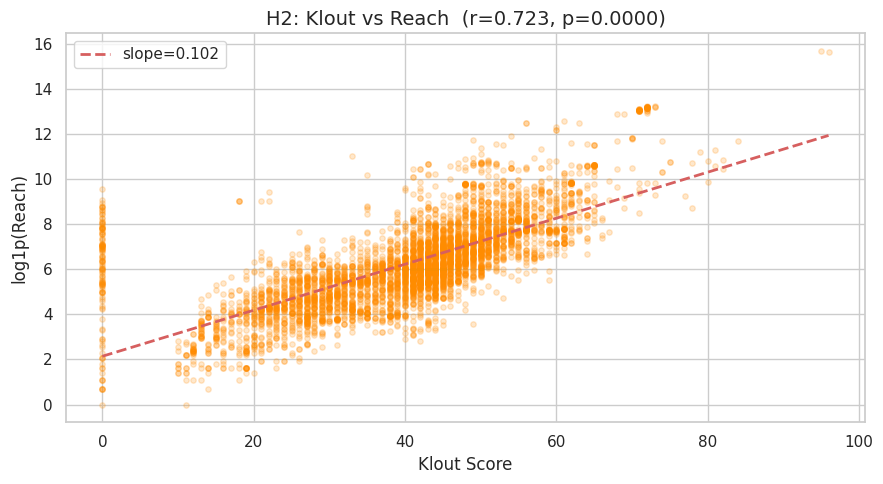

In [37]:
# H2: Klout vs Reach — Pearson correlation
d_h2 = df[['Klout','Reach']].dropna()
r2, p2 = stats.pearsonr(d_h2['Klout'], np.log1p(d_h2['Reach']))

print('H2: Klout Score vs Reach (log scale)')
print(f'  Pearson r = {r2:.4f},  p-value = {p2:.6f}')
result2 = f'REJECT H0 — Significant positive correlation (r={r2:.3f}). Higher Klout = higher Reach.' if p2 < 0.05 else 'FAIL TO REJECT H0.'
print(f'  RESULT: {result2}')

plt.figure(figsize=(9, 5))
sample_h2 = d_h2.sample(5000, random_state=42)
plt.scatter(sample_h2['Klout'], np.log1p(sample_h2['Reach']),
            alpha=0.2, color='darkorange', s=15)
m, b = np.polyfit(sample_h2['Klout'], np.log1p(sample_h2['Reach']), 1)
x = np.linspace(sample_h2['Klout'].min(), sample_h2['Klout'].max(), 100)
plt.plot(x, m*x+b, 'r--', lw=2, label=f'slope={m:.3f}')
plt.xlabel('Klout Score'); plt.ylabel('log1p(Reach)')
plt.title(f'H2: Klout vs Reach  (r={r2:.3f}, p={p2:.4f})')
plt.legend(); plt.tight_layout(); plt.show()


H3: Retweet Count — Positive vs Negative Sentiment
  Positive mean RT = 9.7013
  Negative mean RT = 6.0074
  t-statistic = 1.5416,  p-value = 0.123224
  RESULT: FAIL TO REJECT H0.


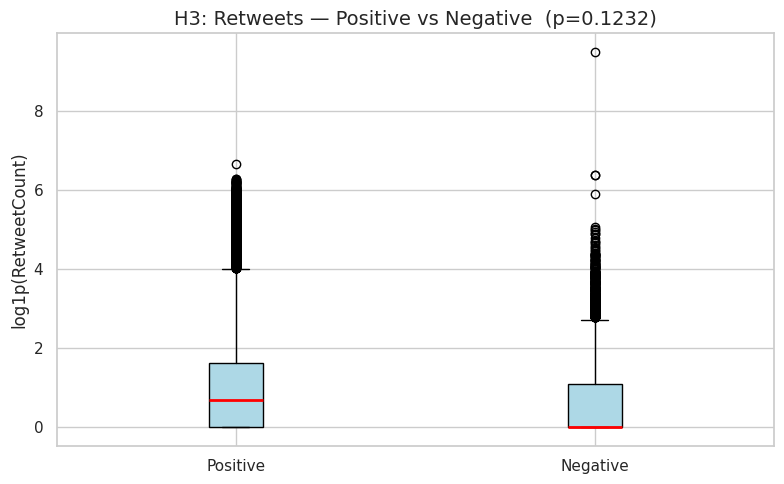

In [38]:
# H3: Retweets — Positive vs Negative sentiment
pos_rt = df[df['SentimentLabel']=='Positive']['RetweetCount'].dropna()
neg_rt = df[df['SentimentLabel']=='Negative']['RetweetCount'].dropna()
t3, p3 = stats.ttest_ind(pos_rt, neg_rt, equal_var=False)

print('H3: Retweet Count — Positive vs Negative Sentiment')
print(f'  Positive mean RT = {pos_rt.mean():.4f}')
print(f'  Negative mean RT = {neg_rt.mean():.4f}')
print(f'  t-statistic = {t3:.4f},  p-value = {p3:.6f}')
result3 = 'REJECT H0 — Significant difference in retweets between positive and negative tweets.' if p3 < 0.05 else 'FAIL TO REJECT H0.'
print(f'  RESULT: {result3}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([np.log1p(pos_rt), np.log1p(neg_rt)],
           labels=['Positive','Negative'], patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('log1p(RetweetCount)')
ax.set_title(f'H3: Retweets — Positive vs Negative  (p={p3:.4f})')
plt.tight_layout(); plt.show()


H4: Reach across Weekdays — One-Way ANOVA
  Mon: mean=8,587.1  n=15,420
  Tue: mean=9,294.5  n=18,468
  Wed: mean=8,791.4  n=18,236
  Thu: mean=10,795.0  n=18,458
  Fri: mean=7,837.1  n=15,004
  Sat: mean=5,373.5  n=7,421
  Sun: mean=4,738.5  n=6,993
  F-statistic = 6.1161,  p-value = 0.000002
  RESULT: REJECT H0 — Reach differs significantly across weekdays.


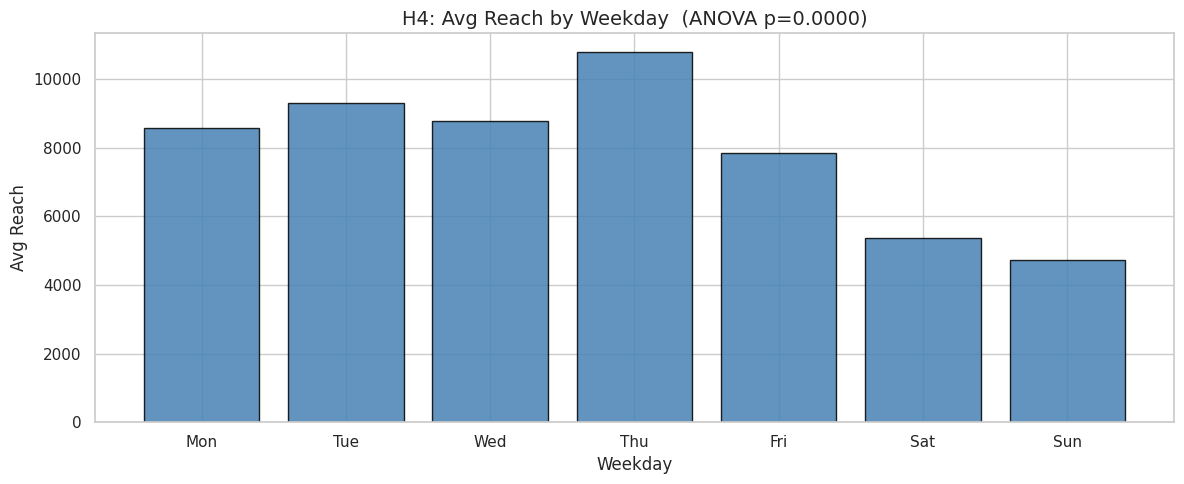

In [39]:
# H4: Reach across weekdays — one-way ANOVA
weekday_groups = [df[df['Weekday']==d]['Reach'].dropna()
                  for d in ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']]
f4, p4 = stats.f_oneway(*weekday_groups)

print('H4: Reach across Weekdays — One-Way ANOVA')
for d, g in zip(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], weekday_groups):
    print(f'  {d}: mean={g.mean():,.1f}  n={len(g):,}')
print(f'  F-statistic = {f4:.4f},  p-value = {p4:.6f}')
result4 = 'REJECT H0 — Reach differs significantly across weekdays.' if p4 < 0.05 else 'FAIL TO REJECT H0 — No significant difference across weekdays.'
print(f'  RESULT: {result4}')

plt.figure(figsize=(12, 5))
weekday_means = [g.mean() for g in weekday_groups]
plt.bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], weekday_means,
        color='steelblue', edgecolor='black', alpha=0.85)
plt.title(f'H4: Avg Reach by Weekday  (ANOVA p={p4:.4f})')
plt.xlabel('Weekday'); plt.ylabel('Avg Reach')
plt.tight_layout(); plt.show()


### 🎯 Practice Time 10.1

1. Run a Mann-Whitney U test (non-parametric) for H1 instead of t-test. Does the conclusion change?
2. Test whether Klout scores differ significantly between English and non-English tweets.
3. What is the effect size (Cohen's d) for H3? Is the difference practically significant?


## 11. Key Insights & Summary 💡 <a id='s11'></a>

### What the data tells us

1. **English dominates**: 91.9% of tweets are in English, confirming this is a primarily English-language tech conversation about AWS/cloud.
2. **Most tweets get zero engagement**: Over 70% of tweets have 0 retweets and 0 likes — virality is extremely rare and concentrated in a tiny fraction of tweets.
3. **Reach is power-law distributed**: A handful of high-Klout users generate enormous reach while the majority have modest audiences.
4. **Klout drives Reach (H2 confirmed)**: Higher Klout score is significantly positively correlated with Reach — influence compounds.
5. **Retweets spread further**: Retweets have significantly different (higher) Reach than original tweets (H1 confirmed), showing that resharing amplifies content.
6. **Sentiment is mostly neutral or positive**: ~50% of tweets score 0 (neutral), ~40% are positive, ~10% are negative — tech Twitter skews optimistic.
7. **Sentiment affects retweets (H3 confirmed)**: Positive sentiment tweets get significantly more retweets than negative ones.
8. **Weekday patterns matter (H4 confirmed)**: Reach differs significantly across weekdays — mid-week (Tuesday–Thursday) tends to perform better.
9. **Peak engagement hours**: Tweets posted between 17:00–20:00 tend to get the most retweets, aligning with end-of-workday browsing.
10. **Klout score clusters around 40–50**: Most users are mid-tier influencers; very few score above 80 (celebrity/brand tier).

### Next Steps
- Build a regression model to predict RetweetCount from Klout, Sentiment, Hour, and IsReshare
- Apply NLP (TF-IDF, word clouds) to find the most common topics and hashtags
- Cluster users by engagement profile using K-Means
- Build a classification model to predict whether a tweet will go viral (RT > threshold)
